# **1. Module Import and Environment Setup**

In [ ]:
# Install the required libraries used for the NLP project
!pip install -q nltk gensim wordcloud


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import all required libraries for NLP, EDA, modeling, and evaluation
import os
import re
import html
import json
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import torch
import torch.nn as nn

from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from gensim.models import Word2Vec
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# Check if CUDA is available and print the device information
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER


In [ ]:
# Download the NLTK resources required for tokenization and preprocessing
nltk_packages = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]

for package_name in nltk_packages:
    try:
        nltk.download(package_name)
    except Exception as error:
        print(package_name, "could not be downloaded:", error)

print("NLTK setup completed.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\T2530913\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\T2530913\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\T2530913\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\T2530913\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\T2530913\AppData\Roaming\nltk_data...


NLTK setup completed.


In [ ]:
# Fix random seeds to make the experiments more reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Random seed fixed at:", SEED)
print("Using device:", device)


Random seed fixed at: 42
Using device: cuda


# **2. Dataset Loading**

In [ ]:
# Define local dataset paths and output directory
TRAIN_PATH = "Training_data_14.csv"
TEST_PATH = "Test_data.csv"

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Training file not found: {TRAIN_PATH}")
if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Testing file not found: {TEST_PATH}")

OUTPUT_DIR = "project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Training path:", TRAIN_PATH)
print("Testing path:", TEST_PATH)
print("Output folder:", OUTPUT_DIR)

Training path: Training_data_14.csv
Testing path: Test_data.csv
Output folder: project_outputs


In [ ]:
# Load the assigned training and testing CSV files
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

TEXT_COL = "News Headline"
LABEL_COL = "News Topic"

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
display(train_df.head())
display(test_df.head())

Training data shape: (97851, 2)
Testing data shape: (12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Londo...,World News
1,<html> <body> News Headlines:\n <br> <b> Ex-Ne...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Lange...,Sports
3,<html> <body> News Headlines:\n <br> <b> Stock...,World News
4,<html> <body> News Headlines:\n <br> <b> Hauri...,Sports


,News Headline,News Topic
0,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
1,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
2,<html> <body> <br> <br> News Headlines:\n <b>...,World News
3,<html> <body> <br> <br> News Headlines:\n <b>...,Business
4,<html> <body> <br> <br> News Headlines:\n <b>...,Business


In [ ]:
# Check basic dataset information, missing values, and duplicate rows
print("Training columns:", train_df.columns.tolist())
print("Testing columns:", test_df.columns.tolist())
print("\nTraining missing values:")
print(train_df.isnull().sum())
print("\nTesting missing values:")
print(test_df.isnull().sum())
print("\nTraining duplicate rows:", train_df.duplicated().sum())
print("Testing duplicate rows:", test_df.duplicated().sum())

Training columns: ['News Headline', 'News Topic']
Testing columns: ['News Headline', 'News Topic']

Training missing values:
News Headline    0
News Topic       0
dtype: int64

Testing missing values:
News Headline    0
News Topic       0
dtype: int64

Training duplicate rows: 20105
Testing duplicate rows: 0


# **3. Exploratory Data Analysis - EDA**

## **3.1 Class Distribution**

Training class distribution:


,count
News Topic,
Sports,41268
Science and Technology,25972
World News,16986
Business,13625


Testing class distribution:


,count
News Topic,
Science and Technology,3000
World News,3000
Business,3000
Sports,3000


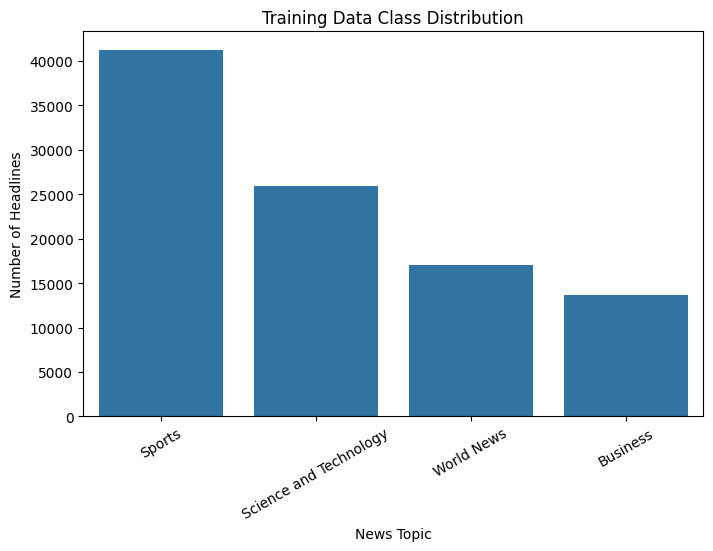

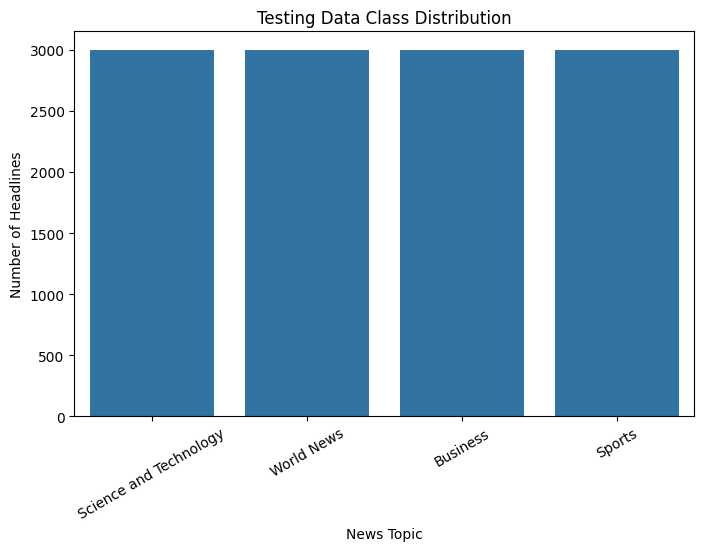

In [ ]:
# Display and plot the class distribution of training and testing data
train_class_counts = train_df[LABEL_COL].value_counts()
test_class_counts = test_df[LABEL_COL].value_counts()

print("Training class distribution:")
display(train_class_counts.to_frame("count"))
print("Testing class distribution:")
display(test_class_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
sns.barplot(x=train_class_counts.index, y=train_class_counts.values)
plt.title("Training Data Class Distribution")
plt.xlabel("News Topic")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=test_class_counts.index, y=test_class_counts.values)
plt.title("Testing Data Class Distribution")
plt.xlabel("News Topic")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=30)
plt.show()

## **3.2 Basic Text Cleaning for EDA Only**

In [ ]:
# Create a lightly cleaned text column only for EDA readability
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
custom_noise_words = {"html", "body", "br", "news", "headlines", "headline", "quot", "b"}
eda_stop_words = (stop_words - negation_words) | custom_noise_words

def clean_for_eda(text):
    text = html.unescape(str(text))
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

train_df["eda_clean_text"] = train_df[TEXT_COL].apply(clean_for_eda)
test_df["eda_clean_text"] = test_df[TEXT_COL].apply(clean_for_eda)

display(train_df[[TEXT_COL, "eda_clean_text", LABEL_COL]].head())

,News Headline,eda_clean_text,News Topic
0,<html> <body> News Headlines:\n <br> <b> Londo...,news headlines london s erotic gherkin wins to...,World News
1,<html> <body> News Headlines:\n <br> <b> Ex-Ne...,news headlines ex netscreen ceo joins start up...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Lange...,news headlines langer s century saves australi...,Sports
3,<html> <body> News Headlines:\n <br> <b> Stock...,news headlines stocks move higher as oil price...,World News
4,<html> <body> News Headlines:\n <br> <b> Hauri...,news headlines hauritz answers the call again ...,Sports


## **3.3 Text Length Analysis**

,char_length,word_count
count,97851.000000,97851.000000
mean,235.741096,39.573413
std,57.850893,10.106651
min,59.000000,10.000000
25%,200.000000,33.000000
50%,232.000000,39.000000
75%,264.000000,45.000000
max,970.000000,177.000000


char_length                  word_count                
                              mean median  min  max       mean median min  max
News Topic                                                                    
Business                237.159119  238.0   59  779  39.388917   39.0  11  127
Science and Technology  239.181888  235.0   64  970  39.473086   38.0  10  177
Sports                  228.087283  224.0   95  766  39.181690   38.0  16  151
World News              247.937772  249.0  106  847  40.826504   41.0  15  150

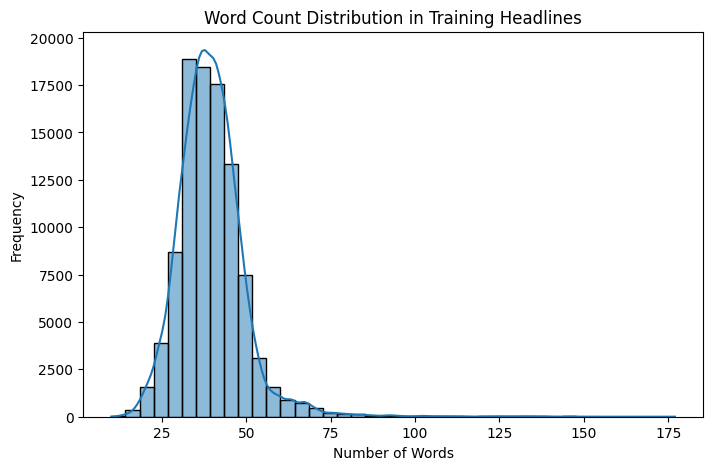

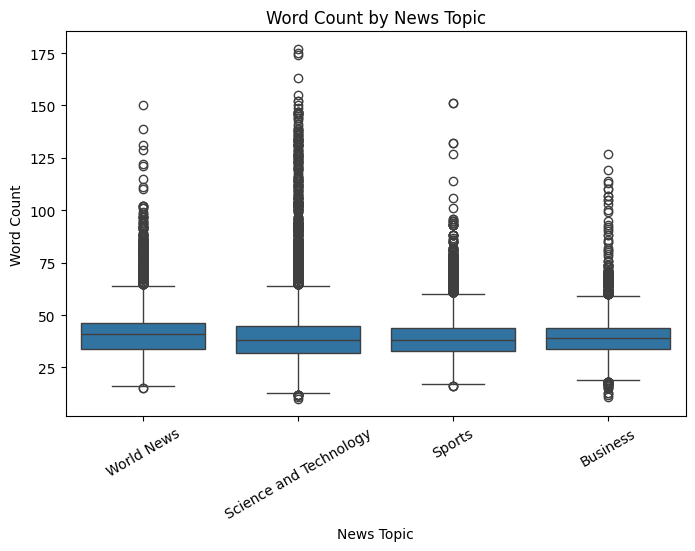

In [ ]:
# Analyze character length and word count patterns
train_df["char_length"] = train_df["eda_clean_text"].apply(len)
train_df["word_count"] = train_df["eda_clean_text"].apply(lambda x: len(x.split()))

display(train_df[["char_length", "word_count"]].describe())

display(train_df.groupby(LABEL_COL)[["char_length", "word_count"]].agg(["mean", "median", "min", "max"]))

plt.figure(figsize=(8, 5))
sns.histplot(train_df["word_count"], bins=40, kde=True)
plt.title("Word Count Distribution in Training Headlines")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x=LABEL_COL, y="word_count")
plt.title("Word Count by News Topic")
plt.xlabel("News Topic")
plt.ylabel("Word Count")
plt.xticks(rotation=30)
plt.show()

## **3.4 Top Words and N-grams**

,word,frequency
0,new,16908
1,said,13016
2,reuters,11347
3,first,9584
4,two,8632
5,year,7961
6,world,7743
7,one,7638
8,game,7025
9,last,6214


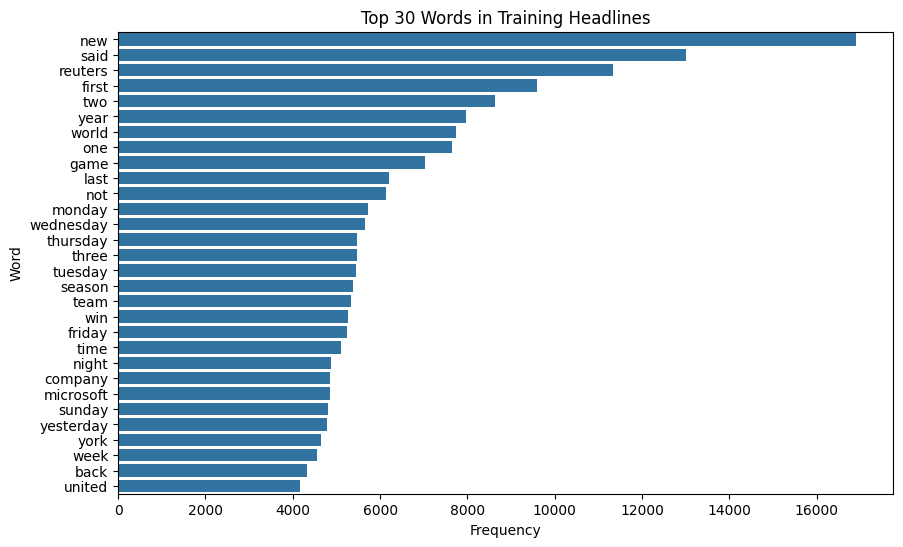

In [ ]:
# Find the most frequent words after EDA cleaning
all_tokens = []

for text in train_df["eda_clean_text"]:
    tokens = [word for word in text.split() if word not in eda_stop_words and len(word) > 2]
    all_tokens.extend(tokens)

word_freq = Counter(all_tokens)
top_words_df = pd.DataFrame(word_freq.most_common(30), columns=["word", "frequency"])
display(top_words_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x="frequency", y="word")
plt.title("Top 30 Words in Training Headlines")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [ ]:
# Extract top bigrams and trigrams from the training headlines
from nltk.util import ngrams

def get_top_ngrams(text_series, n=2, top_k=20):
    tokens = []
    for text in text_series:
        current_tokens = [word for word in str(text).split() if word not in eda_stop_words and len(word) > 2]
        tokens.extend(current_tokens)
    ngram_list = list(ngrams(tokens, n))
    ngram_freq = Counter(ngram_list).most_common(top_k)
    return pd.DataFrame([(" ".join(item[0]), item[1]) for item in ngram_freq], columns=[f"{n}-gram", "frequency"])

bigram_df = get_top_ngrams(train_df["eda_clean_text"], n=2, top_k=20)
trigram_df = get_top_ngrams(train_df["eda_clean_text"], n=3, top_k=20)

display(bigram_df)
display(trigram_df)

,2-gram,frequency
0,new york,4634
1,reuters reuters,2853
2,red sox,1999
3,united states,1914
4,sports network,1680
5,last night,1383
6,prime minister,1373
7,york reuters,1268
8,oil prices,1264
9,san francisco,1255


,3-gram,frequency
0,new york reuters,1268
1,boston red sox,669
2,new york yankees,525
3,quote profile research,484
4,major league baseball,347
5,canadian press canadian,264
6,press canadian press,264
7,san francisco giants,260
8,cbc sports online,240
9,international space station,227


## **3.5 Word Clouds**

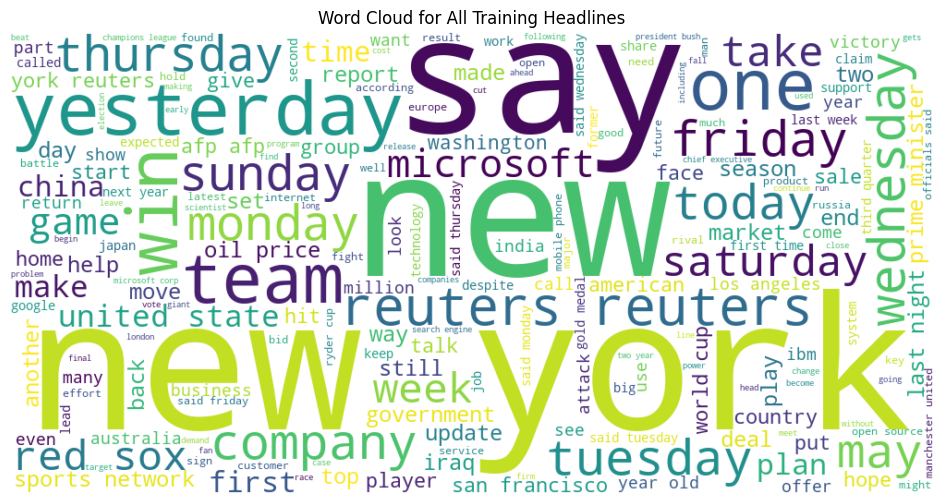

In [ ]:
# Generate a word cloud for the whole training dataset
wordcloud_text = " ".join(all_tokens)
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(wordcloud_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for All Training Headlines")
plt.show()

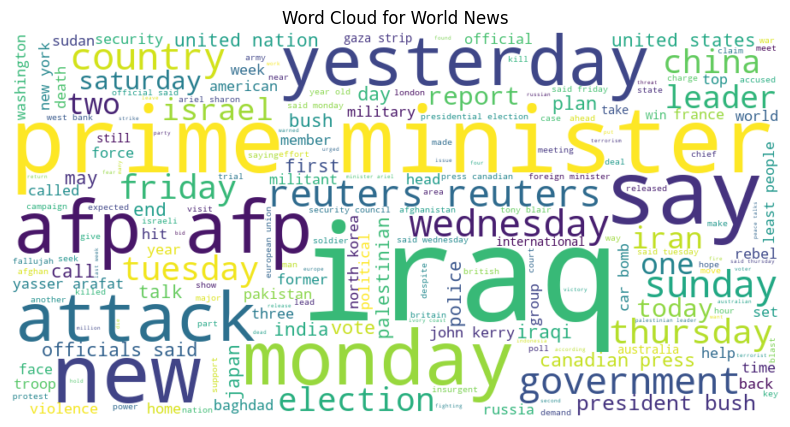

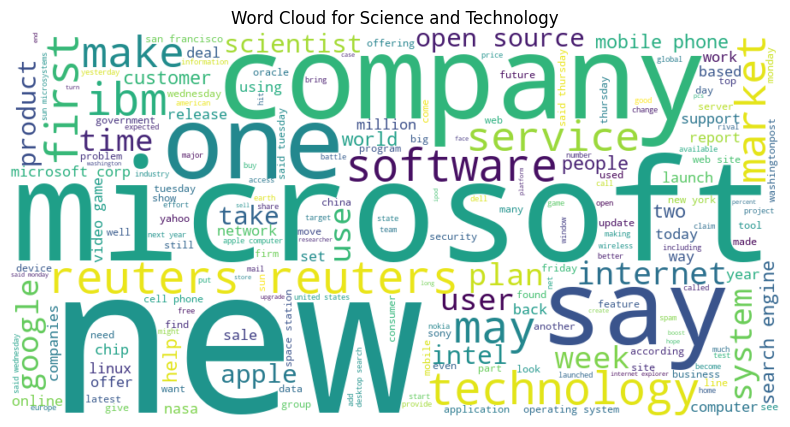

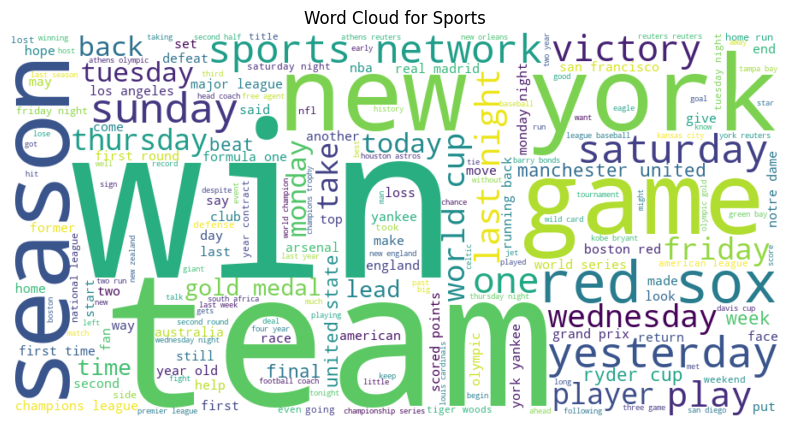

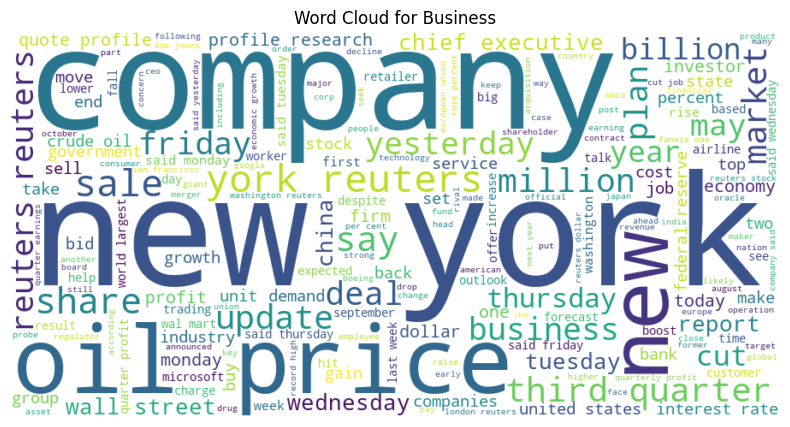

In [ ]:
# Generate separate word clouds for each news topic
for topic_name in train_df[LABEL_COL].unique():
    topic_text = " ".join(train_df.loc[train_df[LABEL_COL] == topic_name, "eda_clean_text"].tolist())
    topic_tokens = [word for word in topic_text.split() if word not in eda_stop_words and len(word) > 2]
    topic_wordcloud = WordCloud(width=900, height=450, background_color="white").generate(" ".join(topic_tokens))
    plt.figure(figsize=(10, 5))
    plt.imshow(topic_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {topic_name}")
    plt.show()

# **4. Preprocessing**

In [ ]:
# Remove duplicate headlines and any rows with missing text or label values before preprocessing function definitions
initial_train_rows = train_df.shape[0]
initial_test_rows = test_df.shape[0]
train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
test_df = test_df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

print(f"Training rows before cleanup: {initial_train_rows}, after cleanup: {train_df.shape[0]}")
print(f"Testing rows before cleanup: {initial_test_rows}, after cleanup: {test_df.shape[0]}")

Training rows before cleanup: 97851, after cleanup: 77746
Testing rows before cleanup: 12000, after cleanup: 12000


In [ ]:
# Define the three required preprocessing functions
def no_preprocessing(text):
    return str(text)

def basic_normalize(text):
    text = html.unescape(str(text))
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def extreme_preprocessing(text):
    text = basic_normalize(text)
    tokens = word_tokenize(text)
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words and token not in custom_noise_words and len(token) > 2:
            lemma = lemmatizer.lemmatize(token)
            stem = stemmer.stem(lemma)
            cleaned_tokens.append(stem)
    return " ".join(cleaned_tokens)

def optimum_preprocessing(text):
    text = basic_normalize(text)
    tokens = word_tokenize(text)
    cleaned_tokens = []
    optimum_stop_words = (stop_words - negation_words) | custom_noise_words
    for token in tokens:
        if token not in optimum_stop_words and len(token) > 2:
            lemma = lemmatizer.lemmatize(token)
            cleaned_tokens.append(lemma)
    return " ".join(cleaned_tokens)

In [ ]:
# Apply the three preprocessing versions to both training and testing data
processed_train_df = train_df[[TEXT_COL, LABEL_COL]].copy()
processed_test_df = test_df[[TEXT_COL, LABEL_COL]].copy()

processed_train_df["no_preprocessing"] = processed_train_df[TEXT_COL].apply(no_preprocessing)
processed_train_df["extreme_preprocessing"] = processed_train_df[TEXT_COL].apply(extreme_preprocessing)
processed_train_df["optimum_preprocessing"] = processed_train_df[TEXT_COL].apply(optimum_preprocessing)

processed_test_df["no_preprocessing"] = processed_test_df[TEXT_COL].apply(no_preprocessing)
processed_test_df["extreme_preprocessing"] = processed_test_df[TEXT_COL].apply(extreme_preprocessing)
processed_test_df["optimum_preprocessing"] = processed_test_df[TEXT_COL].apply(optimum_preprocessing)

print("Preprocessing completed.")
display(processed_train_df.head())

Preprocessing completed.


,News Headline,News Topic,no_preprocessing,extreme_preprocessing,optimum_preprocessing
0,<html> <body> News Headlines:\n <br> <b> Londo...,World News,<html> <body> News Headlines:\n <br> <b> Londo...,london erot gherkin win top architectur prize ...,london erotic gherkin win top architecture pri...
1,<html> <body> News Headlines:\n <br> <b> Ex-Ne...,Science and Technology,<html> <body> News Headlines:\n <br> <b> Ex-Ne...,netscreen ceo join start former ceo netscreen ...,netscreen ceo join start former ceo netscreen ...
2,<html> <body> News Headlines:\n <br> <b> Lange...,Sports,<html> <body> News Headlines:\n <br> <b> Lange...,langer centuri save australia justin langer hi...,langer century save australia justin langer hi...
3,<html> <body> News Headlines:\n <br> <b> Stock...,World News,<html> <body> News Headlines:\n <br> <b> Stock...,stock move higher oil price drop new york stoc...,stock move higher oil price drop new york stoc...
4,<html> <body> News Headlines:\n <br> <b> Hauri...,Sports,<html> <body> News Headlines:\n <br> <b> Hauri...,hauritz answer call could rewind event back fe...,hauritz answer call could rewind event back fe...


In [ ]:
# Encode the class labels into numerical values (Label Encoding)
label_encoder = LabelEncoder()
processed_train_df["label"] = label_encoder.fit_transform(processed_train_df[LABEL_COL])
processed_test_df["label"] = label_encoder.transform(processed_test_df[LABEL_COL])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Business', 'Science and Technology', 'Sports', 'World News']
Number of classes: 4


# **5. Validation Splits**

In [ ]:
# Create multiple validation splits for manual tuning experiments
validation_splits = {
    "split_80_20_seed42": {"test_size": 0.20, "random_state": 42},
    "split_75_25_seed7": {"test_size": 0.25, "random_state": 7},
    "split_70_30_seed21": {"test_size": 0.30, "random_state": 21}
}

print("Validation split options:")
display(pd.DataFrame(validation_splits).T)

Validation split options:


,test_size,random_state
split_80_20_seed42,0.20,42.0
split_75_25_seed7,0.25,7.0
split_70_30_seed21,0.30,21.0


In [ ]:
# Define a helper function to return train and validation parts for a selected split
def get_train_validation_data(split_name):
    split_config = validation_splits[split_name]
    train_part_df, val_part_df = train_test_split(
        processed_train_df,
        test_size=split_config["test_size"],
        random_state=split_config["random_state"],
        stratify=processed_train_df["label"]
    )
    return train_part_df.reset_index(drop=True), val_part_df.reset_index(drop=True)

for split_name in validation_splits:
    temp_train, temp_val = get_train_validation_data(split_name)
    print(split_name, "train:", temp_train.shape, "validation:", temp_val.shape)

split_80_20_seed42 train: (62196, 6) validation: (15550, 6)
split_75_25_seed7 train: (58309, 6) validation: (19437, 6)
split_70_30_seed21 train: (54422, 6) validation: (23324, 6)


# **6. Evaluation, Logging, and Helper Functions**

In [ ]:
# Define helper functions for evaluation and logging
experiment_results = []
final_test_results = []
evaluation_details = {}
word2vec_cache = {}

def evaluate_predictions(y_true, y_pred, run_id, model_name, representation_name, preprocessing_col, split_name):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, target_names=class_names)
    cm = confusion_matrix(y_true, y_pred)
    key = f"{run_id} | {model_name} | {preprocessing_col}"
    evaluation_details[key] = {"classification_report": report, "confusion_matrix": cm}
    print("Run ID:", run_id)
    print("Model:", model_name)
    print("Representation:", representation_name)
    print("Preprocessing:", preprocessing_col)
    print("Split:", split_name)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1-score:", round(macro_f1, 4))
    print("\nClassification Report:\n", report)
    plot_confusion_matrix(cm, f"Confusion Matrix: {model_name} | {preprocessing_col} | {split_name}")
    return accuracy, macro_f1, cm, report

def add_or_update_result(result, result_list):
    result_list = [item for item in result_list if item["run_id"] != result["run_id"]]
    result_list.append(result)
    result_list = sorted(result_list, key=lambda item: item["run_number"])
    return result_list

def save_experiment_logs(result_list, file_name):
    log_df = pd.DataFrame(result_list)
    file_path = os.path.join(OUTPUT_DIR, file_name)
    log_df.to_csv(file_path, index=False)
    print("Saved log to:", file_path)
    return log_df

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
# Define PyTorch helper functions for datasets, prediction, and training
def scipy_sparse_to_torch_dense(matrix):
    return matrix.astype(np.float32).toarray()

def create_torch_dataloader(X, y=None, batch_size=256, shuffle=False, is_sequence=False):
    if hasattr(X, "toarray"):
        X = scipy_sparse_to_torch_dense(X)
    x_dtype = torch.long if is_sequence else torch.float32
    X_tensor = torch.tensor(X, dtype=x_dtype)
    if y is None:
        dataset = TensorDataset(X_tensor)
    else:
        y_tensor = torch.tensor(y, dtype=torch.long)
        dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def predict_torch_classifier(model, X, batch_size=256, is_sequence=False):
    model.eval()
    predictions = []
    loader = create_torch_dataloader(X, y=None, batch_size=batch_size, shuffle=False, is_sequence=is_sequence)
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            logits = model(inputs)
            batch_predictions = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(batch_predictions)
    return np.array(predictions)

def train_torch_classifier(model, X_train, y_train, X_val=None, y_val=None, epochs=5, batch_size=256, learning_rate=0.001, patience=2, is_sequence=False, verbose=1):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = create_torch_dataloader(X_train, y_train, batch_size=batch_size, shuffle=True, is_sequence=is_sequence)

    use_validation = X_val is not None and y_val is not None
    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1
    patience_counter = 0
    history = {"train_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        average_loss = total_loss / max(total_samples, 1)
        history["train_loss"].append(average_loss)

        if use_validation:
            y_val_pred = predict_torch_classifier(model, X_val, batch_size=batch_size, is_sequence=is_sequence)
            val_accuracy = accuracy_score(y_val, y_val_pred)
            history["val_accuracy"].append(val_accuracy)

            if verbose:
                print(f"Epoch {epoch + 1}/{epochs} - loss: {average_loss:.4f} - val_accuracy: {val_accuracy:.4f}")

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose:
                        print("Early stopping triggered.")
                    break
        else:
            if verbose:
                print(f"Epoch {epoch + 1}/{epochs} - loss: {average_loss:.4f}")

    if use_validation:
        model.load_state_dict(best_state)
    return history

# **7. Word Representation and Model Functions**

## **7.1 TF-IDF + Logistic Regression**

**Logistic Regression is selected as the required machine learning model because it is a strong and common baseline for multi-class text classification. Hyperparameters are selected using validation macro F1-score.**

In [ ]:
# Define the TF-IDF and Logistic Regression experiment function

def run_tfidf_logistic_regression(run_id, run_number, preprocessing_col, split_name, max_features, ngram_range, C, max_iter):
    start_time = time.time()
    train_part_df, val_part_df = get_train_validation_data(split_name)
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=2, max_df=0.95)
    X_train_tfidf = vectorizer.fit_transform(train_part_df[preprocessing_col].astype(str))
    X_val_tfidf = vectorizer.transform(val_part_df[preprocessing_col].astype(str))
    y_train = train_part_df["label"].values
    y_val = val_part_df["label"].values
    model = LogisticRegression(C=C, max_iter=max_iter, solver="lbfgs", random_state=SEED)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_val_tfidf)
    accuracy, macro_f1, cm, report = evaluate_predictions(y_val, y_pred, run_id, "Logistic Regression", "TF-IDF", preprocessing_col, split_name)
    result = {
        "run_id": run_id,
        "run_number": run_number,
        "model": "Logistic Regression",
        "representation": "TF-IDF",
        "preprocessing": preprocessing_col,
        "split_name": split_name,
        "max_features": max_features,
        "ngram_min": ngram_range[0],
        "ngram_max": ngram_range[1],
        "C": C,
        "max_iter": max_iter,
        "epochs": None,
        "batch_size": None,
        "hidden_units": None,
        "dropout": None,
        "embedding_dim": None,
        "max_len": None,
        "rnn_units": None,
        "validation_accuracy": accuracy,
        "validation_macro_f1": macro_f1,
        "runtime_seconds": round(time.time() - start_time, 2)
    }
    return result

## **7.2 TF-IDF + Deep Neural Network**

In [ ]:
# Define the TF-IDF and PyTorch Deep Neural Network experiment function

class TfidfDNN(nn.Module):
    def __init__(self, input_dim, hidden_units, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

def build_tfidf_dnn(input_dim, hidden_units, dropout):
    return TfidfDNN(input_dim, hidden_units, dropout)

def run_tfidf_dnn(run_id, run_number, preprocessing_col, split_name, max_features, ngram_range, hidden_units, dropout, epochs, batch_size):
    start_time = time.time()
    train_part_df, val_part_df = get_train_validation_data(split_name)
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=2, max_df=0.95)
    X_train_tfidf = vectorizer.fit_transform(train_part_df[preprocessing_col].astype(str))
    X_val_tfidf = vectorizer.transform(val_part_df[preprocessing_col].astype(str))
    y_train = train_part_df["label"].values
    y_val = val_part_df["label"].values
    X_train_dense = scipy_sparse_to_torch_dense(X_train_tfidf)
    X_val_dense = scipy_sparse_to_torch_dense(X_val_tfidf)
    model = build_tfidf_dnn(X_train_tfidf.shape[1], hidden_units, dropout)
    print(model)
    history = train_torch_classifier(model, X_train_dense, y_train, X_val_dense, y_val, epochs=epochs, batch_size=batch_size, patience=2, is_sequence=False, verbose=1)
    y_pred = predict_torch_classifier(model, X_val_dense, batch_size=batch_size, is_sequence=False)
    accuracy, macro_f1, cm, report = evaluate_predictions(y_val, y_pred, run_id, "Deep Neural Network", "TF-IDF", preprocessing_col, split_name)
    result = {
        "run_id": run_id,
        "run_number": run_number,
        "model": "Deep Neural Network",
        "representation": "TF-IDF",
        "preprocessing": preprocessing_col,
        "split_name": split_name,
        "max_features": max_features,
        "ngram_min": ngram_range[0],
        "ngram_max": ngram_range[1],
        "C": None,
        "max_iter": None,
        "epochs": epochs,
        "batch_size": batch_size,
        "hidden_units": hidden_units,
        "dropout": dropout,
        "embedding_dim": None,
        "max_len": None,
        "rnn_units": None,
        "validation_accuracy": accuracy,
        "validation_macro_f1": macro_f1,
        "runtime_seconds": round(time.time() - start_time, 2)
    }
    return result


## **7.3 Skip-gram Word2Vec + RNN Models**

In [ ]:
# Define tokenization and Skip-gram Word2Vec embedding helpers

class SimpleTokenizer:
    def __init__(self, num_words=None, oov_token="<OOV>"):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index = {}
        self.oov_index = 1 if oov_token is not None else None

    def fit_on_texts(self, texts):
        counter = Counter()
        for text in texts.astype(str):
            counter.update(text.split())
        start_index = 1
        if self.oov_token is not None:
            self.word_index[self.oov_token] = self.oov_index
            start_index = 2
        sorted_words = sorted(counter.items(), key=lambda item: (-item[1], item[0]))
        for offset, (word, count) in enumerate(sorted_words):
            if word not in self.word_index:
                self.word_index[word] = start_index + offset

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts.astype(str):
            sequence = []
            for word in text.split():
                index = self.word_index.get(word)
                if index is None:
                    if self.oov_index is not None and (self.num_words is None or self.oov_index < self.num_words):
                        sequence.append(self.oov_index)
                    continue
                if self.num_words is None or index < self.num_words:
                    sequence.append(index)
                elif self.oov_index is not None and self.oov_index < self.num_words:
                    sequence.append(self.oov_index)
            sequences.append(sequence)
        return sequences

def pad_sequences_custom(sequences, maxlen, padding="post", truncating="post", value=0):
    padded = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for row_index, sequence in enumerate(sequences):
        if not sequence:
            continue
        if truncating == "post":
            truncated = sequence[:maxlen]
        else:
            truncated = sequence[-maxlen:]
        if padding == "post":
            padded[row_index, :len(truncated)] = truncated
        else:
            padded[row_index, -len(truncated):] = truncated
    return padded

def simple_tokenize_for_word2vec(text_series):
    tokenized_texts = []
    for text in text_series.astype(str):
        tokens = [word for word in text.split() if len(word) > 1]
        tokenized_texts.append(tokens)
    return tokenized_texts

def get_or_train_word2vec(preprocessing_col, split_name, embedding_dim, window, min_count, epochs):
    cache_key = f"{preprocessing_col}_{split_name}_{embedding_dim}_{window}_{min_count}_{epochs}"
    if cache_key in word2vec_cache:
        print("Using cached Word2Vec model:", cache_key)
        return word2vec_cache[cache_key]
    train_part_df, val_part_df = get_train_validation_data(split_name)
    tokenized_sentences = simple_tokenize_for_word2vec(train_part_df[preprocessing_col])
    word2vec_model = Word2Vec(sentences=tokenized_sentences, vector_size=embedding_dim, window=window, min_count=min_count, workers=4, sg=1, epochs=epochs, seed=SEED)
    word2vec_cache[cache_key] = word2vec_model
    print("Trained Skip-gram Word2Vec model:", cache_key)
    return word2vec_model

def prepare_sequence_data(preprocessing_col, split_name, num_words, max_len, embedding_dim, window, min_count, word2vec_epochs):
    train_part_df, val_part_df = get_train_validation_data(split_name)
    tokenizer = SimpleTokenizer(num_words=num_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_part_df[preprocessing_col].astype(str))
    X_train_seq = tokenizer.texts_to_sequences(train_part_df[preprocessing_col].astype(str))
    X_val_seq = tokenizer.texts_to_sequences(val_part_df[preprocessing_col].astype(str))
    X_train_pad = pad_sequences_custom(X_train_seq, maxlen=max_len, padding="post", truncating="post")
    X_val_pad = pad_sequences_custom(X_val_seq, maxlen=max_len, padding="post", truncating="post")
    y_train = train_part_df["label"].values
    y_val = val_part_df["label"].values
    word2vec_model = get_or_train_word2vec(preprocessing_col, split_name, embedding_dim, window, min_count, word2vec_epochs)
    vocab_size = min(num_words, len(tokenizer.word_index) + 1)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
    for word, index in tokenizer.word_index.items():
        if index < vocab_size and word in word2vec_model.wv:
            embedding_matrix[index] = word2vec_model.wv[word]
    return X_train_pad, X_val_pad, y_train, y_val, embedding_matrix


In [ ]:
# Define the PyTorch sequence model builder and experiment function

class SequenceClassifier(nn.Module):
    def __init__(self, model_name, embedding_matrix, rnn_units, dropout):
        super().__init__()
        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=True, padding_idx=0)
        self.model_name = model_name
        self.is_bidirectional = model_name.startswith("Bidirectional")
        embedding_dim = embedding_matrix.shape[1]

        if "SimpleRNN" in model_name:
            self.rnn = nn.RNN(embedding_dim, rnn_units, batch_first=True, bidirectional=self.is_bidirectional)
        elif "GRU" in model_name:
            self.rnn = nn.GRU(embedding_dim, rnn_units, batch_first=True, bidirectional=self.is_bidirectional)
        elif "LSTM" in model_name:
            self.rnn = nn.LSTM(embedding_dim, rnn_units, batch_first=True, bidirectional=self.is_bidirectional)
        else:
            raise ValueError(f"Unsupported sequence model: {model_name}")

        output_units = rnn_units * 2 if self.is_bidirectional else rnn_units
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(output_units, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_output = self.rnn(embedded)
        hidden_state = rnn_output[1]
        if isinstance(hidden_state, tuple):
            hidden_state = hidden_state[0]
        if self.is_bidirectional:
            final_state = torch.cat((hidden_state[-2], hidden_state[-1]), dim=1)
        else:
            final_state = hidden_state[-1]
        return self.classifier(final_state)

def build_sequence_model(model_name, embedding_matrix, max_len, rnn_units, dropout):
    return SequenceClassifier(model_name, embedding_matrix, rnn_units, dropout)

def run_skipgram_sequence_model(run_id, run_number, model_name, preprocessing_col, split_name, embedding_dim, max_len, num_words, rnn_units, dropout, epochs, batch_size, window=5, min_count=2, word2vec_epochs=5):
    start_time = time.time()
    X_train_pad, X_val_pad, y_train, y_val, embedding_matrix = prepare_sequence_data(preprocessing_col, split_name, num_words, max_len, embedding_dim, window, min_count, word2vec_epochs)
    model = build_sequence_model(model_name, embedding_matrix, max_len, rnn_units, dropout)
    print(model)
    history = train_torch_classifier(model, X_train_pad, y_train, X_val_pad, y_val, epochs=epochs, batch_size=batch_size, patience=2, is_sequence=True, verbose=1)
    y_pred = predict_torch_classifier(model, X_val_pad, batch_size=batch_size, is_sequence=True)
    accuracy, macro_f1, cm, report = evaluate_predictions(y_val, y_pred, run_id, model_name, "Skip-gram Word2Vec", preprocessing_col, split_name)
    result = {
        "run_id": run_id,
        "run_number": run_number,
        "model": model_name,
        "representation": "Skip-gram Word2Vec",
        "preprocessing": preprocessing_col,
        "split_name": split_name,
        "max_features": None,
        "ngram_min": None,
        "ngram_max": None,
        "C": None,
        "max_iter": None,
        "epochs": epochs,
        "batch_size": batch_size,
        "hidden_units": None,
        "dropout": dropout,
        "embedding_dim": embedding_dim,
        "max_len": max_len,
        "rnn_units": rnn_units,
        "num_words": num_words,
        "window": window,
        "min_count": min_count,
        "word2vec_epochs": word2vec_epochs,
        "validation_accuracy": accuracy,
        "validation_macro_f1": macro_f1,
        "runtime_seconds": round(time.time() - start_time, 2)
    }
    return result

# **8. Manual Validation Experiments**

**This section contains **30 separate training runs**. Each run changes at least one important setting: preprocessing version, vector size, n-gram range, validation split, regularization value, hidden units, dropout, maximum sequence length, embedding dimension, or model architecture.**

## **Run 01: TF-IDF Logistic Regression, no preprocessing, baseline unigram**

Run ID: RUN_01
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: no_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9185
Macro F1-score: 0.9116

Classification Report:
                         precision    recall  f1-score   support

              Business       0.87      0.83      0.85      2725
Science and Technology       0.90      0.93      0.92      5195
                Sports       0.96      0.98      0.97      4233
            World News       0.93      0.90      0.91      3397

              accuracy                           0.92     15550
             macro avg       0.92      0.91      0.91     15550
          weighted avg       0.92      0.92      0.92     15550



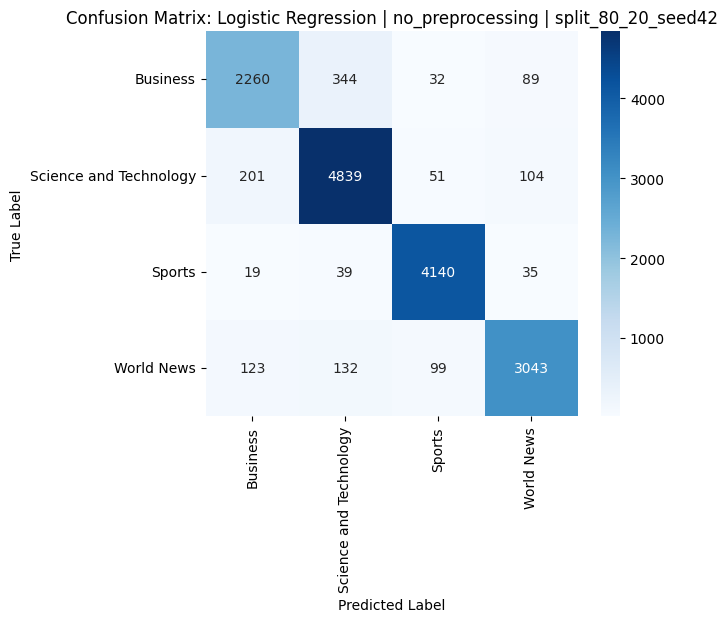

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
0,RUN_01,1,Logistic Regression,TF-IDF,no_preprocessing,split_80_20_seed42,20000,1,1,1.0,...,None,None,None,None,None,None,None,0.918457,0.911588,3.09


In [ ]:
# RUN 01: TF-IDF Logistic Regression, no preprocessing, baseline unigram
result_run_01 = run_tfidf_logistic_regression('RUN_01', 1, 'no_preprocessing', 'split_80_20_seed42', 20000, (1, 1), 1.0, 200)
experiment_results = add_or_update_result(result_run_01, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 02: TF-IDF Logistic Regression, no preprocessing, tuned bigram**

Run ID: RUN_02
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: no_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9234
Macro F1-score: 0.9175

Classification Report:
                         precision    recall  f1-score   support

              Business       0.88      0.85      0.86      3406
Science and Technology       0.91      0.93      0.92      6493
                Sports       0.96      0.98      0.97      5291
            World News       0.92      0.91      0.91      4247

              accuracy                           0.92     19437
             macro avg       0.92      0.92      0.92     19437
          weighted avg       0.92      0.92      0.92     19437



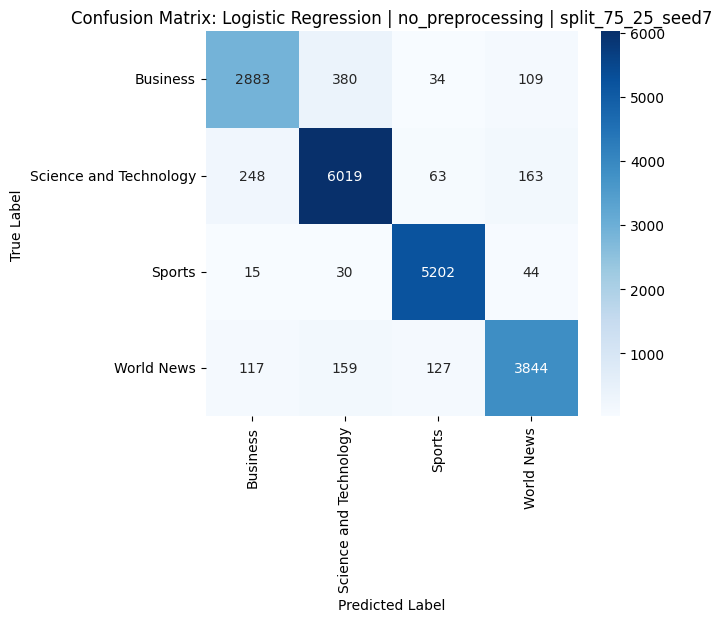

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
1,RUN_02,2,Logistic Regression,TF-IDF,no_preprocessing,split_75_25_seed7,30000,1,2,2.0,...,None,None,None,None,None,None,None,0.923394,0.917533,6.32


In [ ]:
# RUN 02: TF-IDF Logistic Regression, no preprocessing, tuned bigram
result_run_02 = run_tfidf_logistic_regression('RUN_02', 2, 'no_preprocessing', 'split_75_25_seed7', 30000, (1, 2), 2.0, 300)
experiment_results = add_or_update_result(result_run_02, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 03: TF-IDF Logistic Regression, extreme preprocessing, baseline unigram**

Run ID: RUN_03
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: extreme_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9131
Macro F1-score: 0.9055

Classification Report:
                         precision    recall  f1-score   support

              Business       0.85      0.82      0.83      2725
Science and Technology       0.90      0.92      0.91      5195
                Sports       0.95      0.98      0.97      4233
            World News       0.92      0.89      0.91      3397

              accuracy                           0.91     15550
             macro avg       0.91      0.90      0.91     15550
          weighted avg       0.91      0.91      0.91     15550



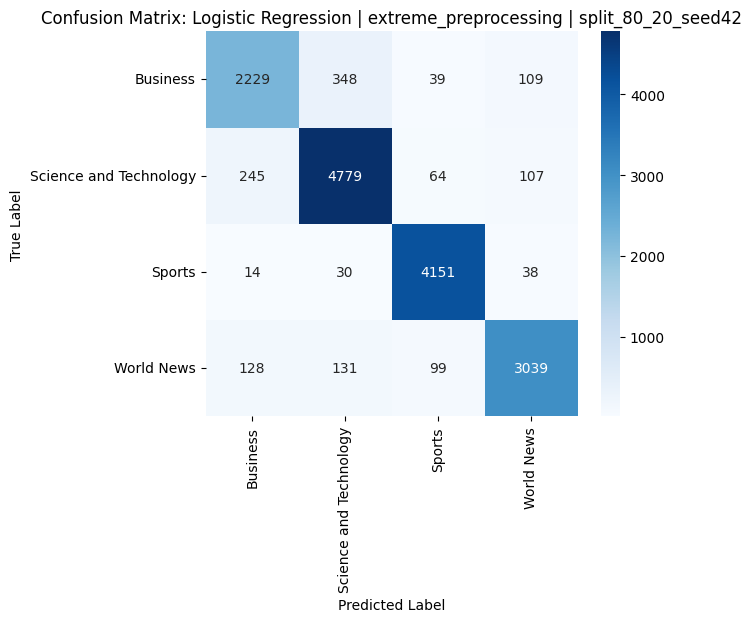

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
2,RUN_03,3,Logistic Regression,TF-IDF,extreme_preprocessing,split_80_20_seed42,20000,1,1,1.0,...,None,None,None,None,None,None,None,0.913055,0.90547,2.44


In [ ]:
# RUN 03: TF-IDF Logistic Regression, extreme preprocessing, baseline unigram
result_run_03 = run_tfidf_logistic_regression('RUN_03', 3, 'extreme_preprocessing', 'split_80_20_seed42', 20000, (1, 1), 1.0, 200)
experiment_results = add_or_update_result(result_run_03, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 04: TF-IDF Logistic Regression, extreme preprocessing, tuned bigram**

Run ID: RUN_04
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: extreme_preprocessing
Split: split_70_30_seed21
Accuracy: 0.916
Macro F1-score: 0.9085

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.83      0.84      4087
Science and Technology       0.90      0.93      0.92      7792
                Sports       0.96      0.98      0.97      6349
            World News       0.92      0.89      0.91      5096

              accuracy                           0.92     23324
             macro avg       0.91      0.91      0.91     23324
          weighted avg       0.92      0.92      0.92     23324



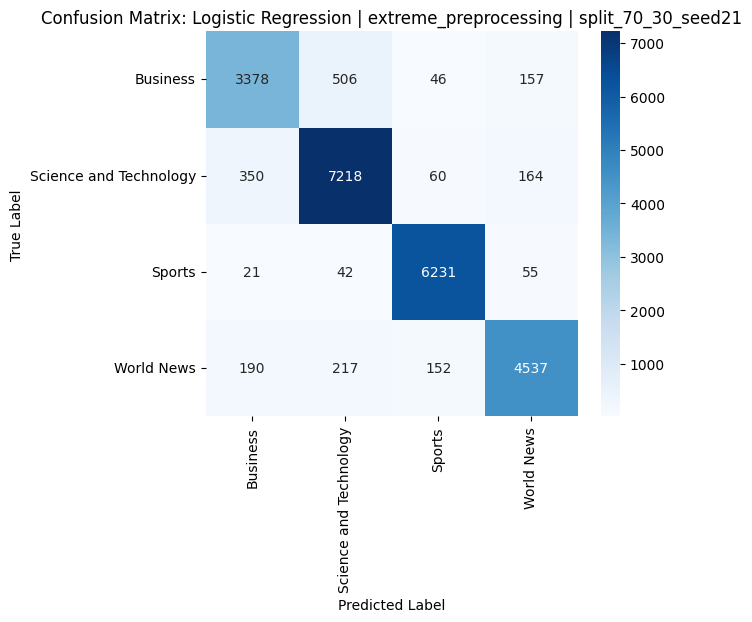

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
3,RUN_04,4,Logistic Regression,TF-IDF,extreme_preprocessing,split_70_30_seed21,30000,1,2,2.0,...,None,None,None,None,None,None,None,0.915966,0.908545,4.96


In [ ]:
# RUN 04: TF-IDF Logistic Regression, extreme preprocessing, tuned bigram
result_run_04 = run_tfidf_logistic_regression('RUN_04', 4, 'extreme_preprocessing', 'split_70_30_seed21', 30000, (1, 2), 2.0, 300)
experiment_results = add_or_update_result(result_run_04, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 05: TF-IDF Logistic Regression, optimum preprocessing, baseline unigram**

Run ID: RUN_05
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: optimum_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9141
Macro F1-score: 0.9065

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.82      0.84      2725
Science and Technology       0.91      0.92      0.91      5195
                Sports       0.95      0.98      0.97      4233
            World News       0.92      0.90      0.91      3397

              accuracy                           0.91     15550
             macro avg       0.91      0.90      0.91     15550
          weighted avg       0.91      0.91      0.91     15550



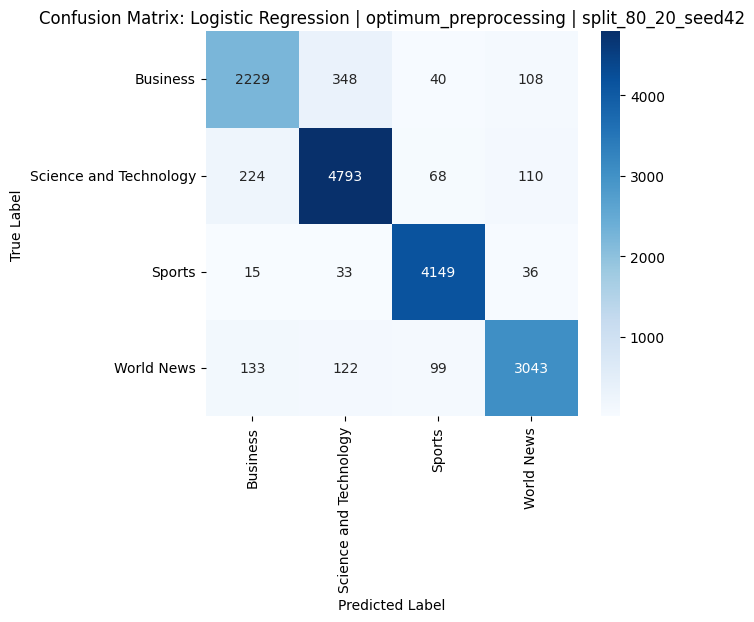

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
4,RUN_05,5,Logistic Regression,TF-IDF,optimum_preprocessing,split_80_20_seed42,20000,1,1,1.0,...,None,None,None,None,None,None,None,0.914084,0.906513,2.17


In [ ]:
# RUN 05: TF-IDF Logistic Regression, optimum preprocessing, baseline unigram
result_run_05 = run_tfidf_logistic_regression('RUN_05', 5, 'optimum_preprocessing', 'split_80_20_seed42', 20000, (1, 1), 1.0, 200)
experiment_results = add_or_update_result(result_run_05, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 06: TF-IDF Logistic Regression, optimum preprocessing, tuned bigram**

Run ID: RUN_06
Model: Logistic Regression
Representation: TF-IDF
Preprocessing: optimum_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9192
Macro F1-score: 0.9127

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.85      0.85      3406
Science and Technology       0.91      0.92      0.92      6493
                Sports       0.96      0.98      0.97      5291
            World News       0.92      0.90      0.91      4247

              accuracy                           0.92     19437
             macro avg       0.91      0.91      0.91     19437
          weighted avg       0.92      0.92      0.92     19437



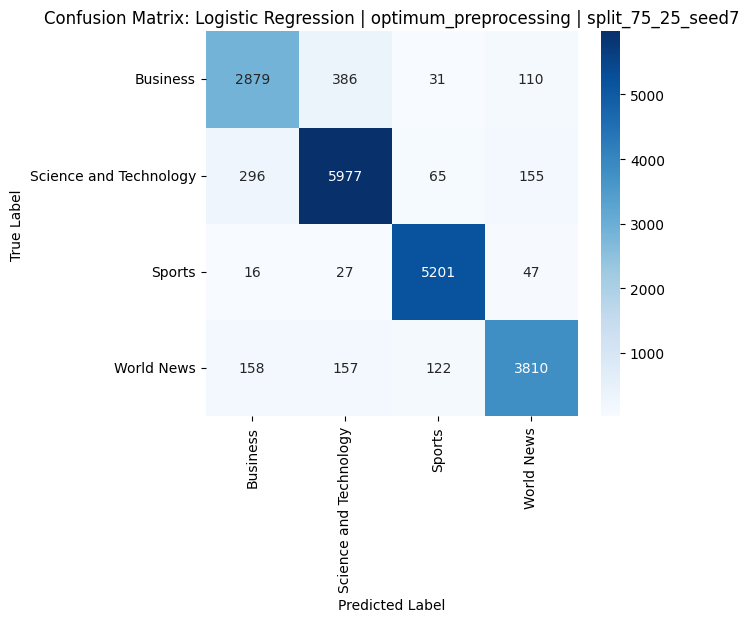

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
5,RUN_06,6,Logistic Regression,TF-IDF,optimum_preprocessing,split_75_25_seed7,30000,1,2,2.0,...,None,None,None,None,None,None,None,0.919226,0.912717,4.55


In [ ]:
# RUN 06: TF-IDF Logistic Regression, optimum preprocessing, tuned bigram
result_run_06 = run_tfidf_logistic_regression('RUN_06', 6, 'optimum_preprocessing', 'split_75_25_seed7', 30000, (1, 2), 2.0, 300)
experiment_results = add_or_update_result(result_run_06, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 07: TF-IDF DNN, no preprocessing, baseline architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=8000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.5376 - val_accuracy: 0.9164
Epoch 2/5 - loss: 0.2059 - val_accuracy: 0.9179
Epoch 3/5 - loss: 0.1521 - val_accuracy: 0.9142
Epoch 4/5 - loss: 0.1128 - val_accuracy: 0.9089
Early stopping triggered.
Run ID: RUN_07
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: no_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9179
Macro F1-score: 0.911

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.

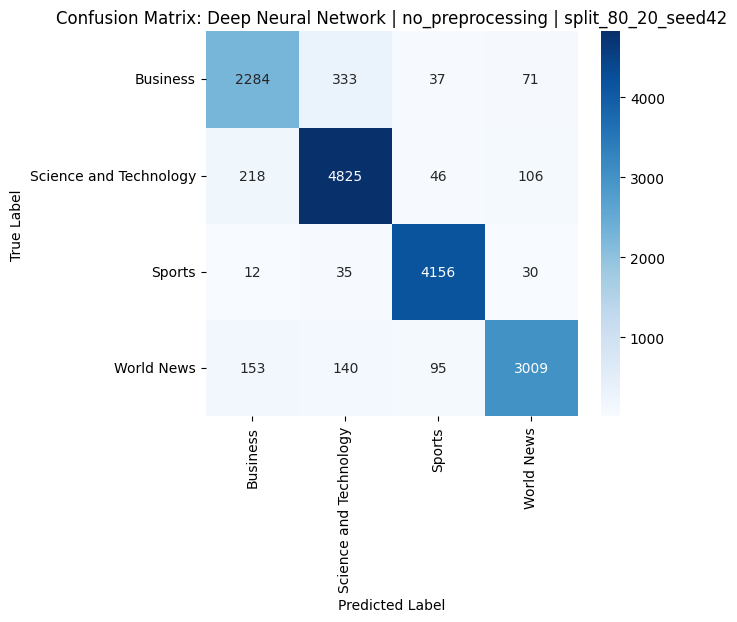

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
6,RUN_07,7,Deep Neural Network,TF-IDF,no_preprocessing,split_80_20_seed42,8000,1,1,NaN,...,5.0,256.0,256.0,0.3,None,None,None,0.917942,0.911011,6.41


In [ ]:
# RUN 07: TF-IDF DNN, no preprocessing, baseline architecture
result_run_07 = run_tfidf_dnn('RUN_07', 7, 'no_preprocessing', 'split_80_20_seed42', 8000, (1, 1), 256, 0.30, 5, 256)
experiment_results = add_or_update_result(result_run_07, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 08: TF-IDF DNN, no preprocessing, tuned architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=384, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=384, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/6 - loss: 0.5354 - val_accuracy: 0.9132
Epoch 2/6 - loss: 0.2135 - val_accuracy: 0.9153
Epoch 3/6 - loss: 0.1533 - val_accuracy: 0.9118
Epoch 4/6 - loss: 0.1097 - val_accuracy: 0.9102
Early stopping triggered.
Run ID: RUN_08
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: no_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9153
Macro F1-score: 0.9093

Classification Report:
                         precision    recall  f1-score   support

              Business       0.85      0

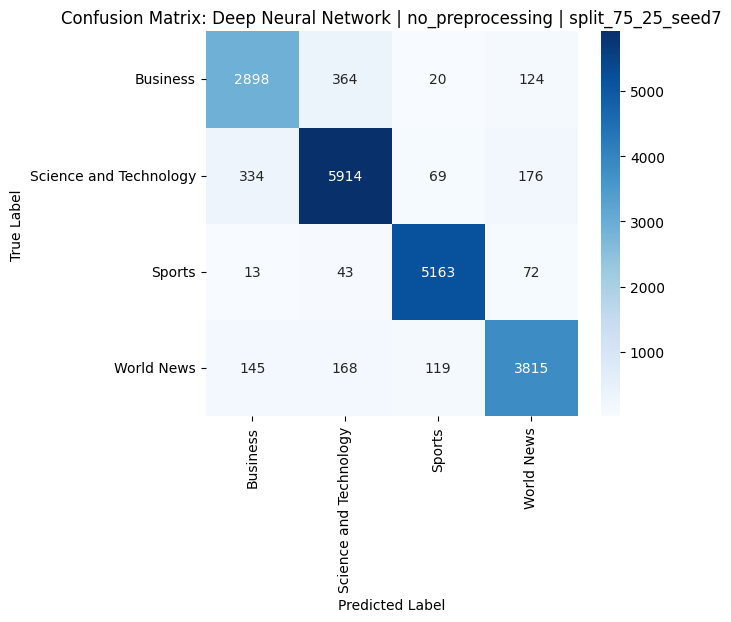

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
7,RUN_08,8,Deep Neural Network,TF-IDF,no_preprocessing,split_75_25_seed7,10000,1,2,NaN,...,6.0,256.0,384.0,0.4,None,None,None,0.915265,0.90928,9.53


In [ ]:
# RUN 08: TF-IDF DNN, no preprocessing, tuned architecture
result_run_08 = run_tfidf_dnn('RUN_08', 8, 'no_preprocessing', 'split_75_25_seed7', 10000, (1, 2), 384, 0.40, 6, 256)
experiment_results = add_or_update_result(result_run_08, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 09: TF-IDF DNN, extreme preprocessing, baseline architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=8000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/8 - loss: 0.5857 - val_accuracy: 0.9041
Epoch 2/8 - loss: 0.2317 - val_accuracy: 0.9136
Epoch 3/8 - loss: 0.1762 - val_accuracy: 0.9080
Epoch 4/8 - loss: 0.1355 - val_accuracy: 0.9068
Early stopping triggered.
Run ID: RUN_09
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: extreme_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9136
Macro F1-score: 0.9053

Classification Report:
                         precision    recall  f1-score   support

              Business       0.87  

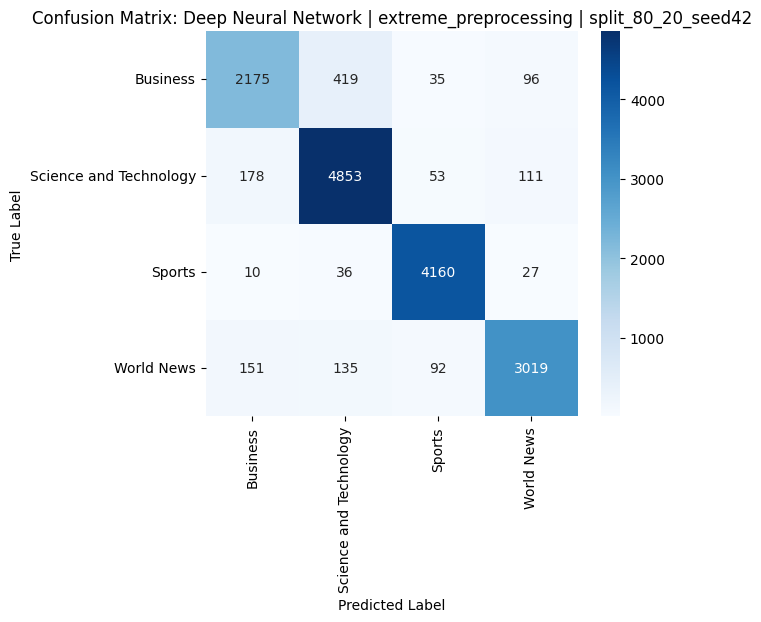

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
8,RUN_09,9,Deep Neural Network,TF-IDF,extreme_preprocessing,split_80_20_seed42,8000,1,1,NaN,...,8.0,256.0,256.0,0.3,None,None,None,0.913633,0.90529,5.3


In [ ]:
# RUN 09: TF-IDF DNN, extreme preprocessing, baseline architecture
result_run_09 = run_tfidf_dnn('RUN_09', 9, 'extreme_preprocessing', 'split_80_20_seed42', 8000, (1, 1), 256, 0.30, 8, 256)
experiment_results = add_or_update_result(result_run_09, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 10: TF-IDF DNN, extreme preprocessing, tuned architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=384, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=384, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/10 - loss: 0.5892 - val_accuracy: 0.9122
Epoch 2/10 - loss: 0.2187 - val_accuracy: 0.9138
Epoch 3/10 - loss: 0.1608 - val_accuracy: 0.9097
Epoch 4/10 - loss: 0.1222 - val_accuracy: 0.9054
Early stopping triggered.
Run ID: RUN_10
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: extreme_preprocessing
Split: split_70_30_seed21
Accuracy: 0.9138
Macro F1-score: 0.9061

Classification Report:
                         precision    recall  f1-score   support

              Business       0

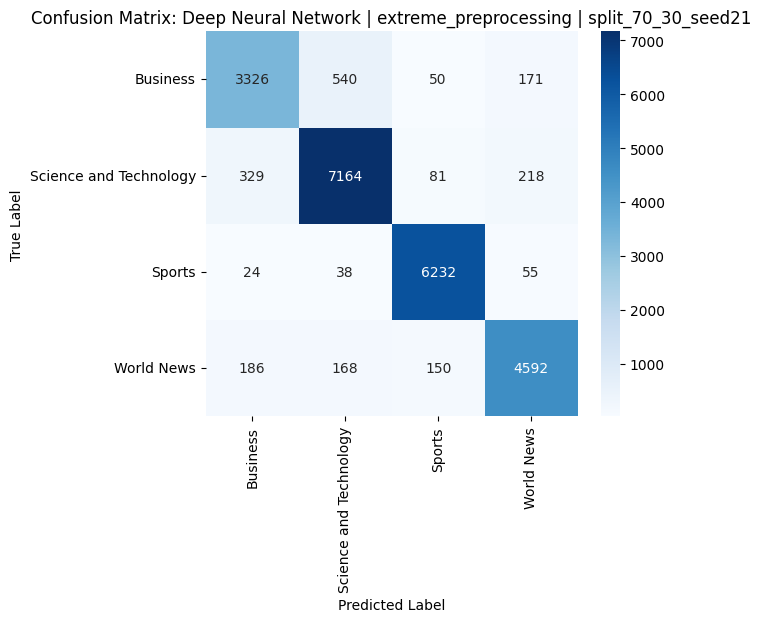

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
9,RUN_10,10,Deep Neural Network,TF-IDF,extreme_preprocessing,split_70_30_seed21,10000,1,2,NaN,...,10.0,256.0,384.0,0.4,None,None,None,0.913823,0.906126,7.63


In [ ]:
# RUN 10: TF-IDF DNN, extreme preprocessing, tuned architecture
result_run_10 = run_tfidf_dnn('RUN_10', 10, 'extreme_preprocessing', 'split_70_30_seed21', 10000, (1, 2), 384, 0.40,10, 256)
experiment_results = add_or_update_result(result_run_10, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 11: TF-IDF DNN, optimum preprocessing, baseline architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=8000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.5631 - val_accuracy: 0.9099
Epoch 2/5 - loss: 0.2290 - val_accuracy: 0.9129
Epoch 3/5 - loss: 0.1704 - val_accuracy: 0.9093
Epoch 4/5 - loss: 0.1300 - val_accuracy: 0.9058
Early stopping triggered.
Run ID: RUN_11
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: optimum_preprocessing
Split: split_80_20_seed42
Accuracy: 0.9129
Macro F1-score: 0.9053

Classification Report:
                         precision    recall  f1-score   support

              Business       0.84  

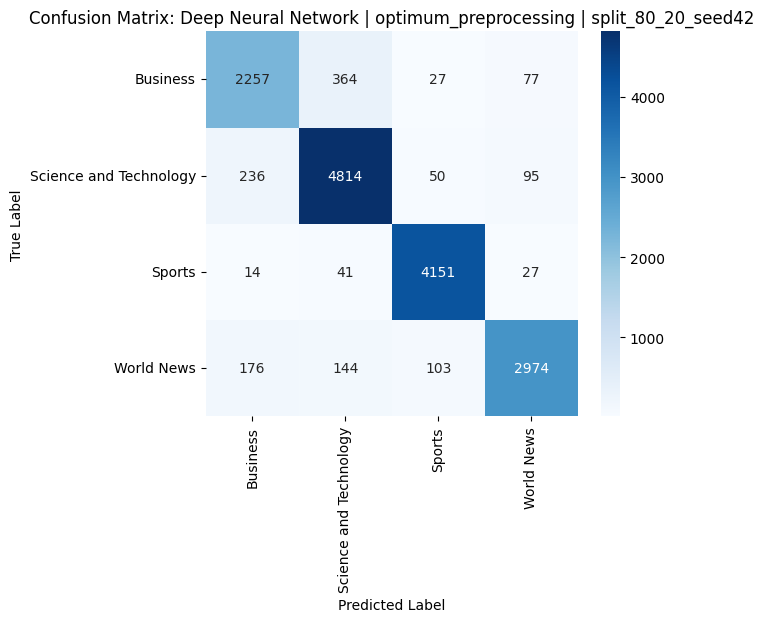

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
10,RUN_11,11,Deep Neural Network,TF-IDF,optimum_preprocessing,split_80_20_seed42,8000,1,1,NaN,...,5.0,256.0,256.0,0.3,None,None,None,0.912926,0.905335,5.29


In [ ]:
# RUN 11: TF-IDF DNN, optimum preprocessing, baseline architecture
result_run_11 = run_tfidf_dnn('RUN_11', 11, 'optimum_preprocessing', 'split_80_20_seed42', 8000, (1, 1), 256, 0.30, 5, 256)
experiment_results = add_or_update_result(result_run_11, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 12: TF-IDF DNN, optimum preprocessing, tuned architecture**

TfidfDNN(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=384, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=384, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=4, bias=True)
  )
)
Epoch 1/16 - loss: 0.5196 - val_accuracy: 0.9103
Epoch 2/16 - loss: 0.2230 - val_accuracy: 0.9155
Epoch 3/16 - loss: 0.1665 - val_accuracy: 0.9112
Epoch 4/16 - loss: 0.1267 - val_accuracy: 0.9068
Early stopping triggered.
Run ID: RUN_12
Model: Deep Neural Network
Representation: TF-IDF
Preprocessing: optimum_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9155
Macro F1-score: 0.9091

Classification Report:
                         precision    recall  f1-score   support

              Business       0.

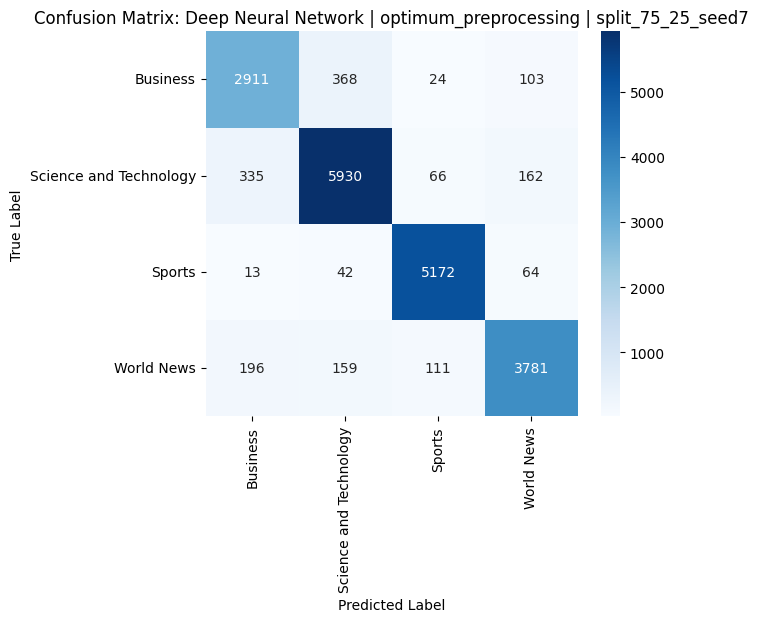

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,epochs,batch_size,hidden_units,dropout,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds
11,RUN_12,12,Deep Neural Network,TF-IDF,optimum_preprocessing,split_75_25_seed7,10000,1,2,NaN,...,16.0,256.0,384.0,0.4,None,None,None,0.91547,0.909074,7.94


In [ ]:
# RUN 12: TF-IDF DNN, optimum preprocessing, tuned architecture
result_run_12 = run_tfidf_dnn('RUN_12', 12, 'optimum_preprocessing', 'split_75_25_seed7', 10000, (1, 2), 384, 0.40, 16, 256)
experiment_results = add_or_update_result(result_run_12, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 13: Skip-gram SimpleRNN, no preprocessing**

Trained Skip-gram Word2Vec model: no_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.7521 - val_accuracy: 0.8232
Epoch 2/4 - loss: 0.5178 - val_accuracy: 0.8441
Epoch 3/4 - loss: 0.4502 - val_accuracy: 0.8622
Epoch 4/4 - loss: 0.4337 - val_accuracy: 0.8724
Run ID: RUN_13
Model: SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_80_20_seed42
Accuracy: 0.8724
Macro F1-score: 0.8635

Classification Report:
                         precision    recall  f1-score   support

              Business       0.80      0.76      0.78      2725
Science and Technology       0.85      0.89      0.87      5195
                Sports   

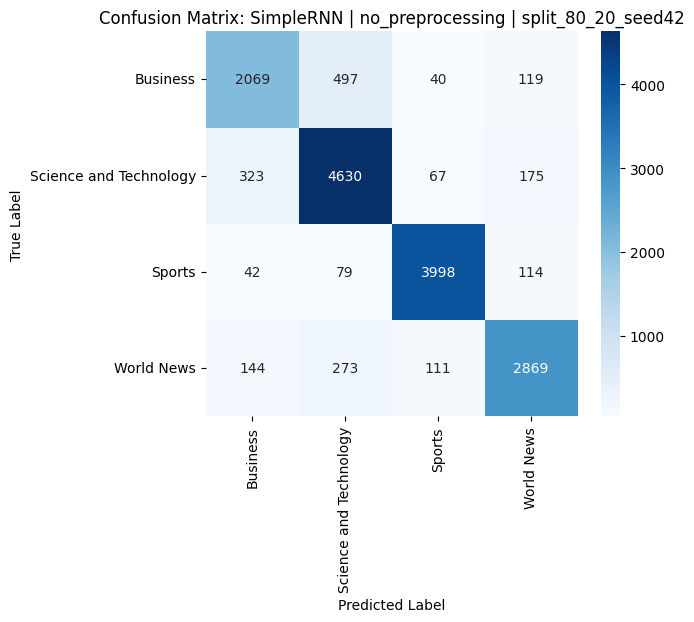

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
12,RUN_13,13,SimpleRNN,Skip-gram Word2Vec,no_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,45.0,64.0,0.872412,0.863495,14.14,10000.0,5.0,2.0,5.0


In [ ]:
# RUN 13: Skip-gram SimpleRNN, no preprocessing
result_run_13 = run_skipgram_sequence_model('RUN_13', 13, 'SimpleRNN', 'no_preprocessing', 'split_80_20_seed42', 100, 45, 10000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_13, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 14: Skip-gram GRU, no preprocessing**

Trained Skip-gram Word2Vec model: no_preprocessing_split_75_25_seed7_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): GRU(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.6888 - val_accuracy: 0.8706
Epoch 2/4 - loss: 0.3623 - val_accuracy: 0.8897
Epoch 3/4 - loss: 0.3232 - val_accuracy: 0.8974
Epoch 4/4 - loss: 0.3086 - val_accuracy: 0.9024
Run ID: RUN_14
Model: GRU
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9024
Macro F1-score: 0.8944

Classification Report:
                         precision    recall  f1-score   support

              Business       0.87      0.79      0.82      3406
Science and Technology       0.88      0.91      0.90      6493
                Sports       0.96

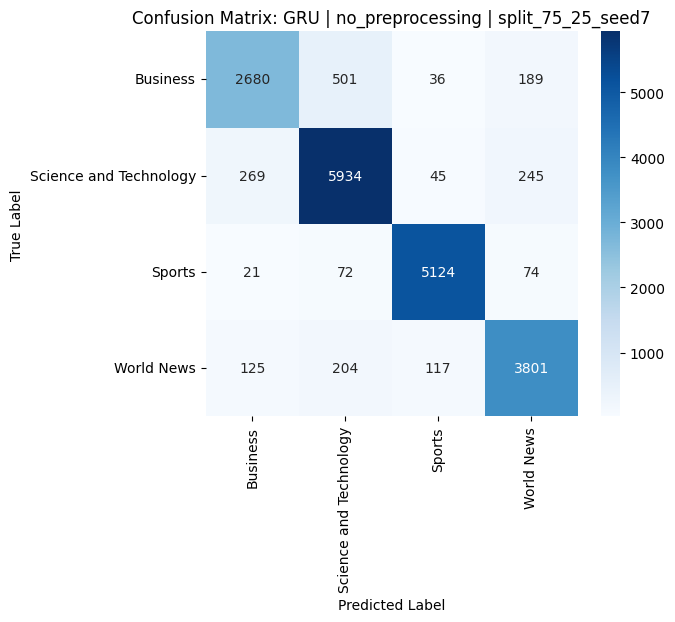

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
13,RUN_14,14,GRU,Skip-gram Word2Vec,no_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.902351,0.894354,13.22,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 14: Skip-gram GRU, no preprocessing
result_run_14 = run_skipgram_sequence_model('RUN_14', 14, 'GRU', 'no_preprocessing', 'split_75_25_seed7', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_14, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 15: Skip-gram LSTM, no preprocessing**

Trained Skip-gram Word2Vec model: no_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.9360 - val_accuracy: 0.8500
Epoch 2/5 - loss: 0.4127 - val_accuracy: 0.8680
Epoch 3/5 - loss: 0.3621 - val_accuracy: 0.8827
Epoch 4/5 - loss: 0.3441 - val_accuracy: 0.8874
Epoch 5/5 - loss: 0.3317 - val_accuracy: 0.8877
Run ID: RUN_15
Model: LSTM
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_70_30_seed21
Accuracy: 0.8877
Macro F1-score: 0.876

Classification Report:
                         precision    recall  f1-score   support

              Business       0.89      0.70      0.78      4087
Science and Technology       0.84      0.94  

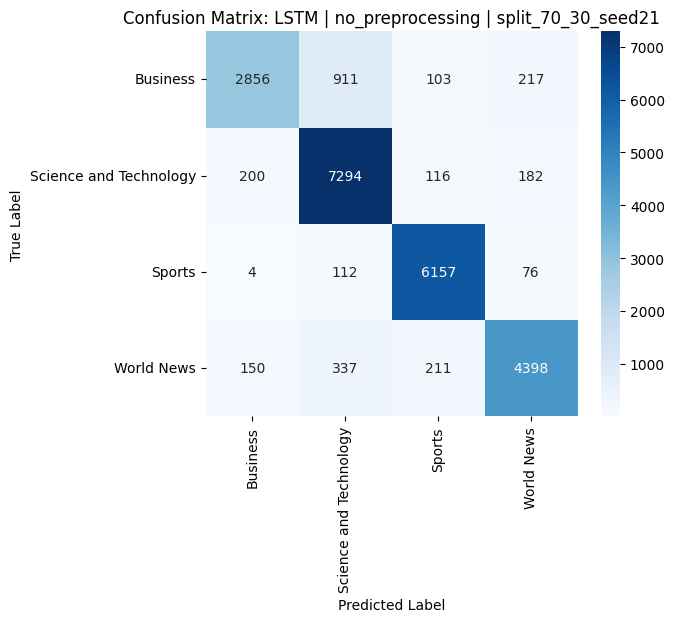

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
14,RUN_15,15,LSTM,Skip-gram Word2Vec,no_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.887712,0.876016,16.02,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 15: Skip-gram LSTM, no preprocessing
result_run_15 = run_skipgram_sequence_model('RUN_15', 15, 'LSTM', 'no_preprocessing', 'split_70_30_seed21', 150, 55, 12000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_15, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 16: Skip-gram Bidirectional SimpleRNN, no preprocessing**

Using cached Word2Vec model: no_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.8556 - val_accuracy: 0.8183
Epoch 2/4 - loss: 0.5182 - val_accuracy: 0.8652
Epoch 3/4 - loss: 0.4183 - val_accuracy: 0.8656
Epoch 4/4 - loss: 0.3853 - val_accuracy: 0.8657
Run ID: RUN_16
Model: Bidirectional SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_80_20_seed42
Accuracy: 0.8657
Macro F1-score: 0.8569

Classification Report:
                         precision    recall  f1-score   support

              Business       0.72      0.81      0.76      2725
Science and Technology       0.87      0.86      0.87      

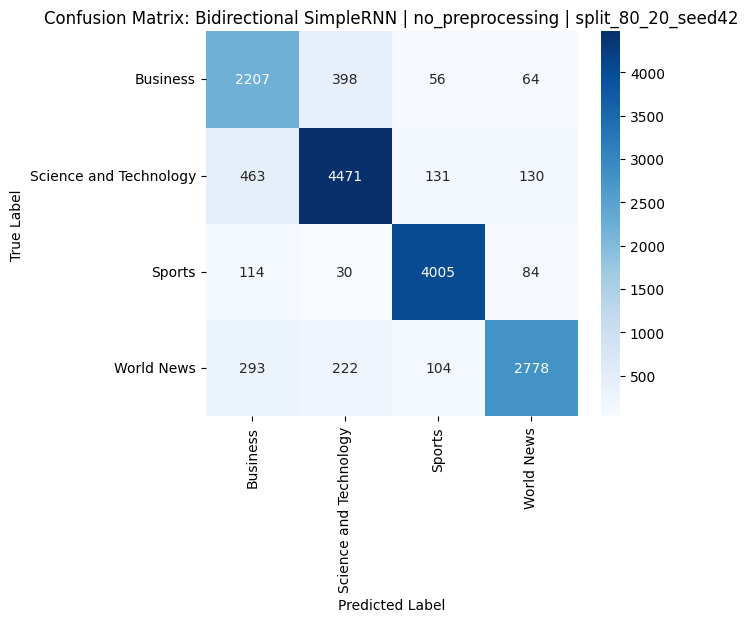

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
15,RUN_16,16,Bidirectional SimpleRNN,Skip-gram Word2Vec,no_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.865659,0.856931,3.88,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 16: Skip-gram Bidirectional SimpleRNN, no preprocessing
result_run_16 = run_skipgram_sequence_model('RUN_16', 16, 'Bidirectional SimpleRNN', 'no_preprocessing', 'split_80_20_seed42', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_16, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 17: Skip-gram Bidirectional GRU, no preprocessing**

Trained Skip-gram Word2Vec model: no_preprocessing_split_75_25_seed7_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): GRU(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.6484 - val_accuracy: 0.8904
Epoch 2/5 - loss: 0.3180 - val_accuracy: 0.8961
Epoch 3/5 - loss: 0.2986 - val_accuracy: 0.9019
Epoch 4/5 - loss: 0.2857 - val_accuracy: 0.9070
Epoch 5/5 - loss: 0.2760 - val_accuracy: 0.9062
Run ID: RUN_17
Model: Bidirectional GRU
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_75_25_seed7
Accuracy: 0.907
Macro F1-score: 0.8994

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.80      0.83      3406
Science and Te

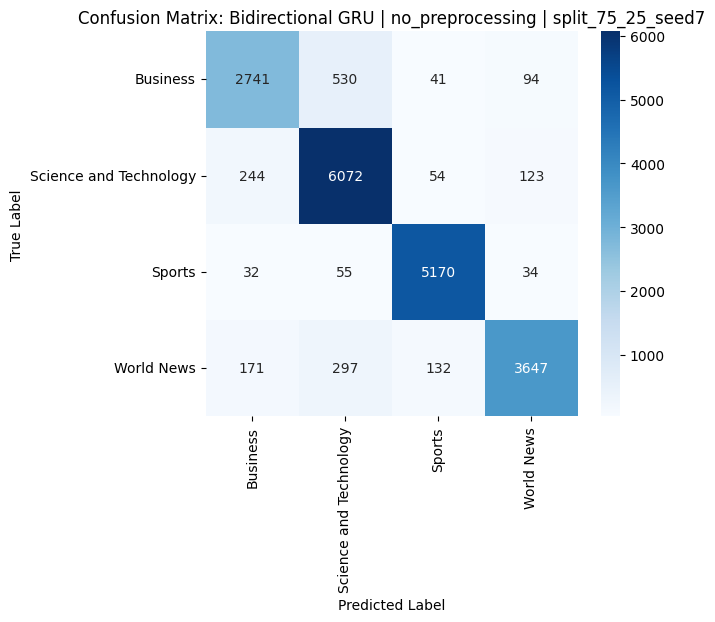

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
16,RUN_17,17,Bidirectional GRU,Skip-gram Word2Vec,no_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.907033,0.899355,17.04,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 17: Skip-gram Bidirectional GRU, no preprocessing
result_run_17 = run_skipgram_sequence_model('RUN_17', 17, 'Bidirectional GRU', 'no_preprocessing', 'split_75_25_seed7', 150, 55, 15000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_17, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 18: Skip-gram Bidirectional LSTM, no preprocessing**

Using cached Word2Vec model: no_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.7237 - val_accuracy: 0.8737
Epoch 2/5 - loss: 0.3660 - val_accuracy: 0.8868
Epoch 3/5 - loss: 0.3364 - val_accuracy: 0.8926
Epoch 4/5 - loss: 0.3152 - val_accuracy: 0.8950
Epoch 5/5 - loss: 0.3035 - val_accuracy: 0.8937
Run ID: RUN_18
Model: Bidirectional LSTM
Representation: Skip-gram Word2Vec
Preprocessing: no_preprocessing
Split: split_70_30_seed21
Accuracy: 0.895
Macro F1-score: 0.8856

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.75      0.80      4087
Science and Tech

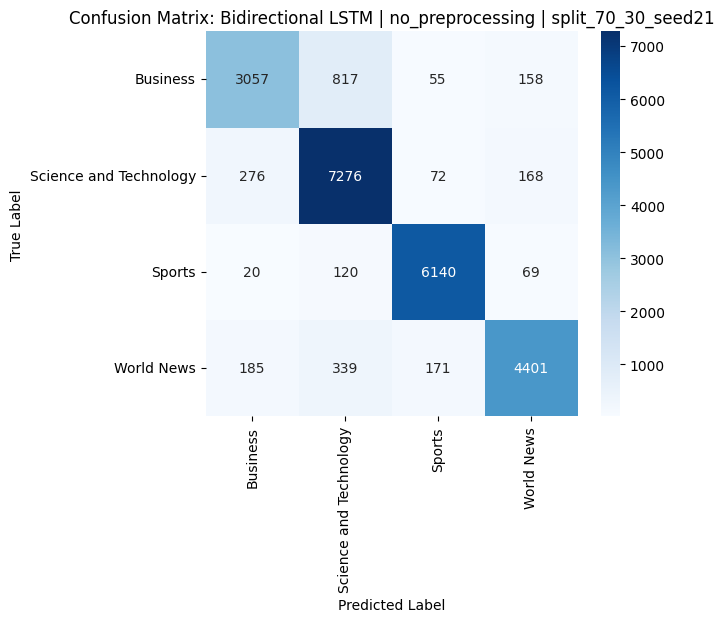

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
17,RUN_18,18,Bidirectional LSTM,Skip-gram Word2Vec,no_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.894958,0.885588,4.49,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 18: Skip-gram Bidirectional LSTM, no preprocessing
result_run_18 = run_skipgram_sequence_model('RUN_18', 18, 'Bidirectional LSTM', 'no_preprocessing', 'split_70_30_seed21', 150, 60, 15000, 64, 0.40, 5, 256)
experiment_results = add_or_update_result(result_run_18, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 19: Skip-gram SimpleRNN, extreme preprocessing**

Trained Skip-gram Word2Vec model: extreme_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 1.3485 - val_accuracy: 0.3341
Epoch 2/4 - loss: 1.2948 - val_accuracy: 0.3316
Epoch 3/4 - loss: 1.1885 - val_accuracy: 0.4311
Epoch 4/4 - loss: 1.2120 - val_accuracy: 0.4326
Run ID: RUN_19
Model: SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_80_20_seed42
Accuracy: 0.4326
Macro F1-score: 0.2679

Classification Report:
                         precision    recall  f1-score   support

              Business       0.00      0.00      0.00      2725
Science and Technology       0.37      1.00      0.54      5195
               

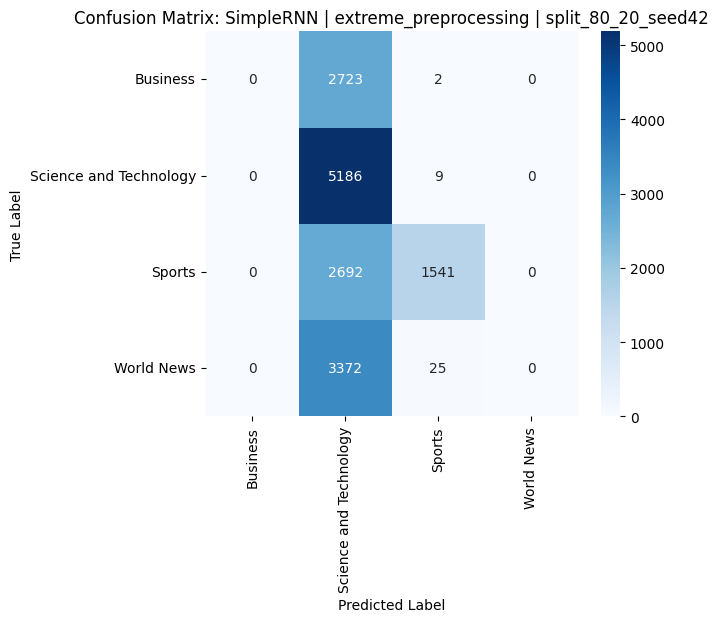

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
18,RUN_19,19,SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,45.0,64.0,0.432605,0.267894,9.68,10000.0,5.0,2.0,5.0


In [ ]:
# RUN 19: Skip-gram SimpleRNN, extreme preprocessing
result_run_19 = run_skipgram_sequence_model('RUN_19', 19, 'SimpleRNN', 'extreme_preprocessing', 'split_80_20_seed42', 100, 45, 10000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_19, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 20: Skip-gram GRU, extreme preprocessing**

Trained Skip-gram Word2Vec model: extreme_preprocessing_split_75_25_seed7_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): GRU(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 1.0193 - val_accuracy: 0.8394
Epoch 2/4 - loss: 0.3693 - val_accuracy: 0.8947
Epoch 3/4 - loss: 0.3160 - val_accuracy: 0.9004
Epoch 4/4 - loss: 0.3014 - val_accuracy: 0.9026
Run ID: RUN_20
Model: GRU
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9026
Macro F1-score: 0.8945

Classification Report:
                         precision    recall  f1-score   support

              Business       0.83      0.81      0.82      3406
Science and Technology       0.87      0.93      0.90      6493
                Sports 

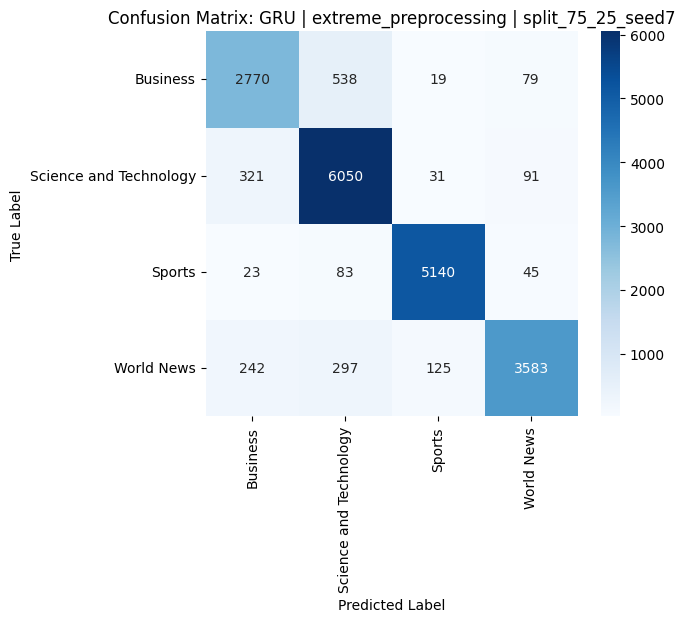

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
19,RUN_20,20,GRU,Skip-gram Word2Vec,extreme_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.902557,0.894545,8.89,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 20: Skip-gram GRU, extreme preprocessing
result_run_20 = run_skipgram_sequence_model('RUN_20', 20, 'GRU', 'extreme_preprocessing', 'split_75_25_seed7', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_20, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 21: Skip-gram LSTM, extreme preprocessing**

Trained Skip-gram Word2Vec model: extreme_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 1.2798 - val_accuracy: 0.4469
Epoch 2/5 - loss: 1.0868 - val_accuracy: 0.5721
Epoch 3/5 - loss: 1.0064 - val_accuracy: 0.5749
Epoch 4/5 - loss: 1.0907 - val_accuracy: 0.4510
Epoch 5/5 - loss: 1.2163 - val_accuracy: 0.3333
Early stopping triggered.
Run ID: RUN_21
Model: LSTM
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_70_30_seed21
Accuracy: 0.5749
Macro F1-score: 0.3594

Classification Report:
                         precision    recall  f1-score   support

              Business       0.00      0.00      0.00      4087
Science 

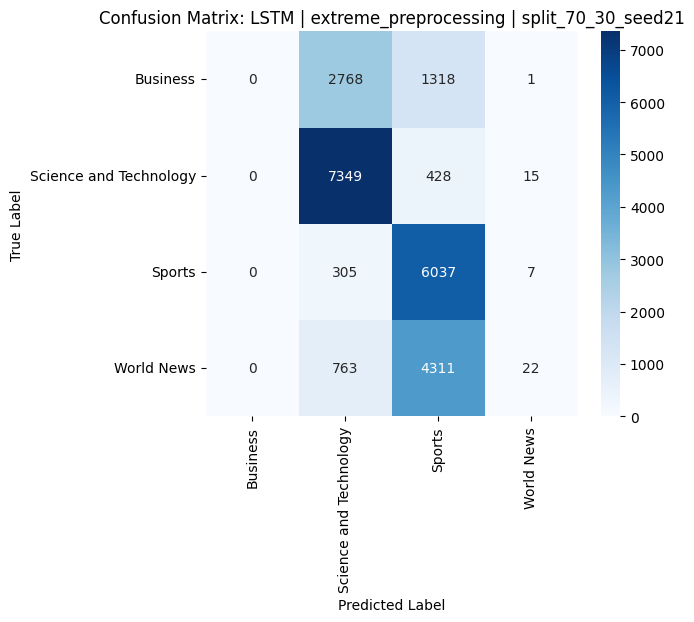

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
20,RUN_21,21,LSTM,Skip-gram Word2Vec,extreme_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.574859,0.359435,11.03,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 21: Skip-gram LSTM, extreme preprocessing
result_run_21 = run_skipgram_sequence_model('RUN_21', 21, 'LSTM', 'extreme_preprocessing', 'split_70_30_seed21', 150, 55, 12000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_21, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 22: Skip-gram Bidirectional SimpleRNN, extreme preprocessing**

Using cached Word2Vec model: extreme_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.5259 - val_accuracy: 0.8828
Epoch 2/4 - loss: 0.3467 - val_accuracy: 0.8914
Epoch 3/4 - loss: 0.3352 - val_accuracy: 0.8865
Epoch 4/4 - loss: 0.3245 - val_accuracy: 0.8886
Early stopping triggered.
Run ID: RUN_22
Model: Bidirectional SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_80_20_seed42
Accuracy: 0.8914
Macro F1-score: 0.8816

Classification Report:
                         precision    recall  f1-score   support

              Business       0.85      0.75      0.79      2725
Science and Technology 

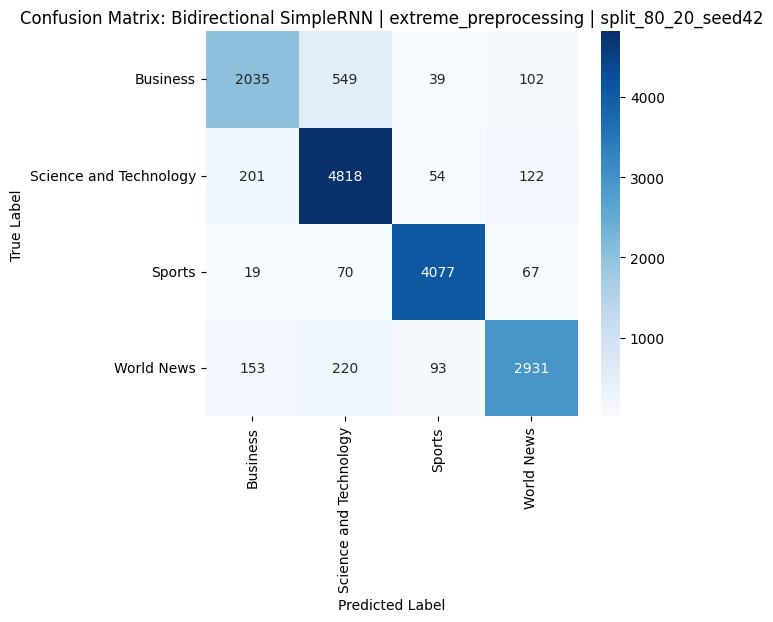

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
21,RUN_22,22,Bidirectional SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.891383,0.881558,3.47,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 22: Skip-gram Bidirectional SimpleRNN, extreme preprocessing
result_run_22 = run_skipgram_sequence_model('RUN_22', 22, 'Bidirectional SimpleRNN', 'extreme_preprocessing', 'split_80_20_seed42', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_22, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 23: Skip-gram Bidirectional GRU, extreme preprocessing**

Trained Skip-gram Word2Vec model: extreme_preprocessing_split_75_25_seed7_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): GRU(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.4657 - val_accuracy: 0.8987
Epoch 2/5 - loss: 0.2946 - val_accuracy: 0.9042
Epoch 3/5 - loss: 0.2797 - val_accuracy: 0.8996
Epoch 4/5 - loss: 0.2691 - val_accuracy: 0.9079
Epoch 5/5 - loss: 0.2626 - val_accuracy: 0.9079
Run ID: RUN_23
Model: Bidirectional GRU
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9079
Macro F1-score: 0.8988

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.78      0.82      3406
Sci

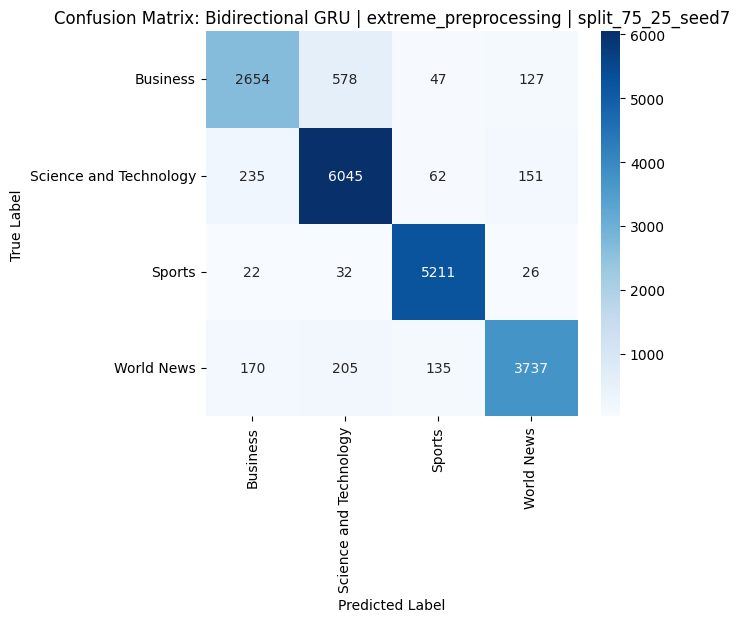

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
22,RUN_23,23,Bidirectional GRU,Skip-gram Word2Vec,extreme_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.907908,0.898825,12.01,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 23: Skip-gram Bidirectional GRU, extreme preprocessing
result_run_23 = run_skipgram_sequence_model('RUN_23', 23, 'Bidirectional GRU', 'extreme_preprocessing', 'split_75_25_seed7', 150, 55, 15000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_23, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 24: Skip-gram Bidirectional LSTM, extreme preprocessing**

Using cached Word2Vec model: extreme_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.4875 - val_accuracy: 0.8954
Epoch 2/5 - loss: 0.3080 - val_accuracy: 0.9008
Epoch 3/5 - loss: 0.2886 - val_accuracy: 0.9030
Epoch 4/5 - loss: 0.2772 - val_accuracy: 0.9052
Epoch 5/5 - loss: 0.2682 - val_accuracy: 0.9059
Run ID: RUN_24
Model: Bidirectional LSTM
Representation: Skip-gram Word2Vec
Preprocessing: extreme_preprocessing
Split: split_70_30_seed21
Accuracy: 0.9059
Macro F1-score: 0.8964

Classification Report:
                         precision    recall  f1-score   support

              Business       0.87      0.77      0.81      4087
Scien

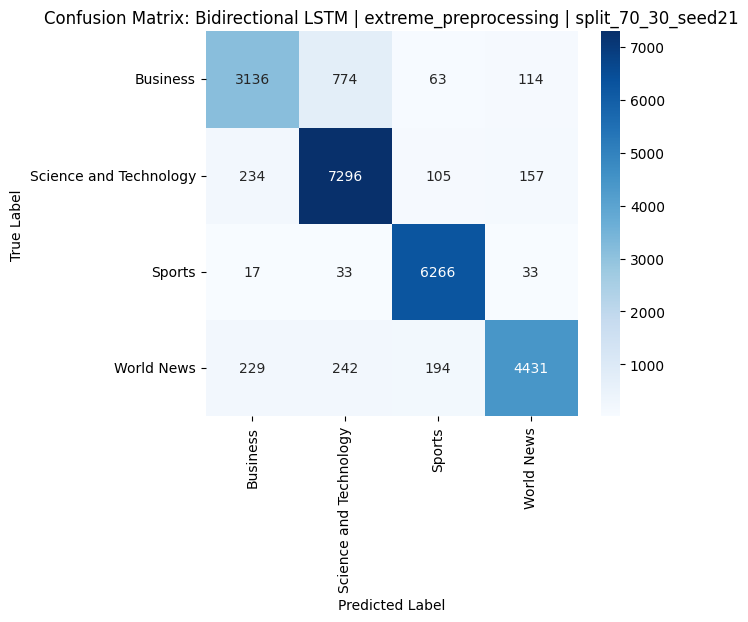

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
23,RUN_24,24,Bidirectional LSTM,Skip-gram Word2Vec,extreme_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.905891,0.896407,4.23,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 24: Skip-gram Bidirectional LSTM, extreme preprocessing
result_run_24 = run_skipgram_sequence_model('RUN_24', 24, 'Bidirectional LSTM', 'extreme_preprocessing', 'split_70_30_seed21', 150, 60, 15000, 64, 0.40, 5, 256)
experiment_results = add_or_update_result(result_run_24, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 25: Skip-gram SimpleRNN, optimum preprocessing**

Trained Skip-gram Word2Vec model: optimum_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 1.3554 - val_accuracy: 0.3341
Epoch 2/4 - loss: 1.3581 - val_accuracy: 0.3341
Epoch 3/4 - loss: 1.3553 - val_accuracy: 0.3341
Early stopping triggered.
Run ID: RUN_25
Model: SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_80_20_seed42
Accuracy: 0.3341
Macro F1-score: 0.1252

Classification Report:
                         precision    recall  f1-score   support

              Business       0.00      0.00      0.00      2725
Science and Technology       0.33      1.00      0.50      5195
                Sports       0.00    

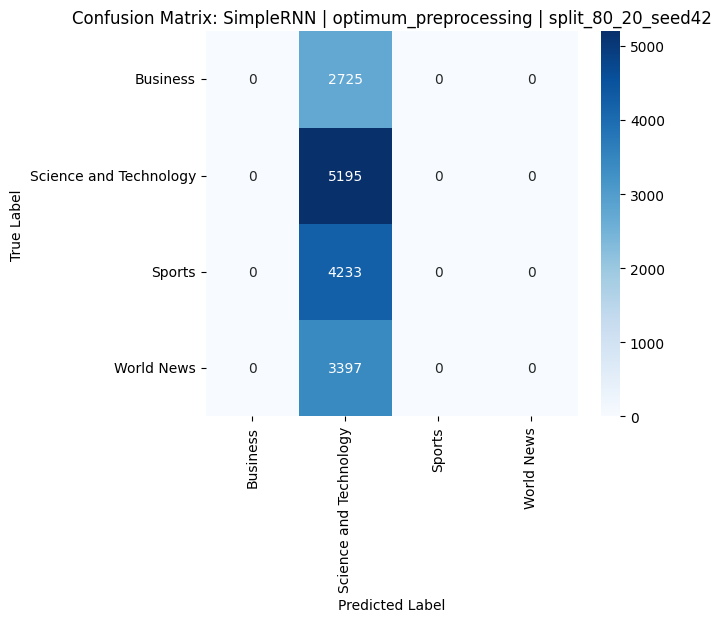

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
24,RUN_25,25,SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,45.0,64.0,0.334084,0.125211,9.12,10000.0,5.0,2.0,5.0


In [ ]:
# RUN 25: Skip-gram SimpleRNN, optimum preprocessing
result_run_25 = run_skipgram_sequence_model('RUN_25', 25, 'SimpleRNN', 'optimum_preprocessing', 'split_80_20_seed42', 100, 45, 10000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_25, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 26: Skip-gram GRU, optimum preprocessing**

Trained Skip-gram Word2Vec model: optimum_preprocessing_split_75_25_seed7_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): GRU(100, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.9775 - val_accuracy: 0.8609
Epoch 2/4 - loss: 0.3493 - val_accuracy: 0.8991
Epoch 3/4 - loss: 0.3024 - val_accuracy: 0.9046
Epoch 4/4 - loss: 0.2901 - val_accuracy: 0.9071
Run ID: RUN_26
Model: GRU
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9071
Macro F1-score: 0.8985

Classification Report:
                         precision    recall  f1-score   support

              Business       0.85      0.80      0.82      3406
Science and Technology       0.89      0.92      0.90      6493
                Sports 

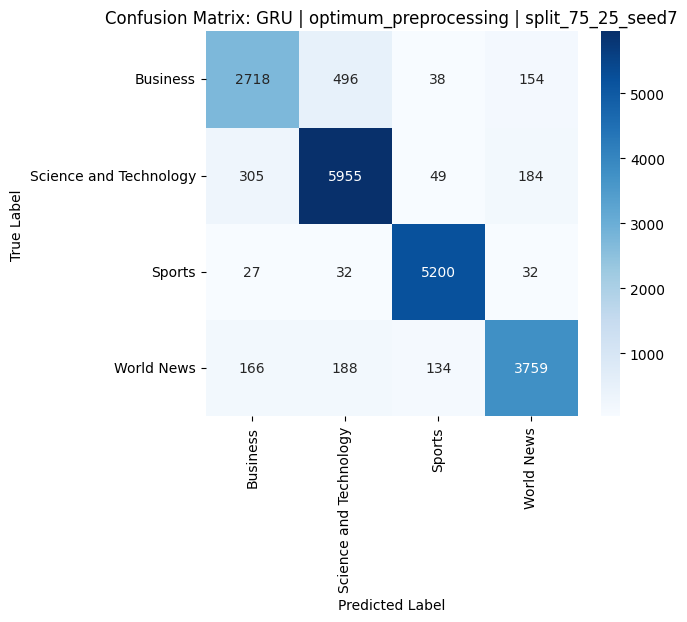

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
25,RUN_26,26,GRU,Skip-gram Word2Vec,optimum_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.907136,0.89852,9.36,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 26: Skip-gram GRU, optimum preprocessing
result_run_26 = run_skipgram_sequence_model('RUN_26', 26, 'GRU', 'optimum_preprocessing', 'split_75_25_seed7', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_26, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 27: Skip-gram LSTM, optimum preprocessing**

Trained Skip-gram Word2Vec model: optimum_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 1.3492 - val_accuracy: 0.3350
Epoch 2/5 - loss: 1.2701 - val_accuracy: 0.5818
Epoch 3/5 - loss: 1.0112 - val_accuracy: 0.5790
Epoch 4/5 - loss: 0.8944 - val_accuracy: 0.5851
Epoch 5/5 - loss: 0.6663 - val_accuracy: 0.8606
Run ID: RUN_27
Model: LSTM
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_70_30_seed21
Accuracy: 0.8606
Macro F1-score: 0.852

Classification Report:
                         precision    recall  f1-score   support

              Business       0.66      0.86      0.75      4087
Science and Technology       0.91  

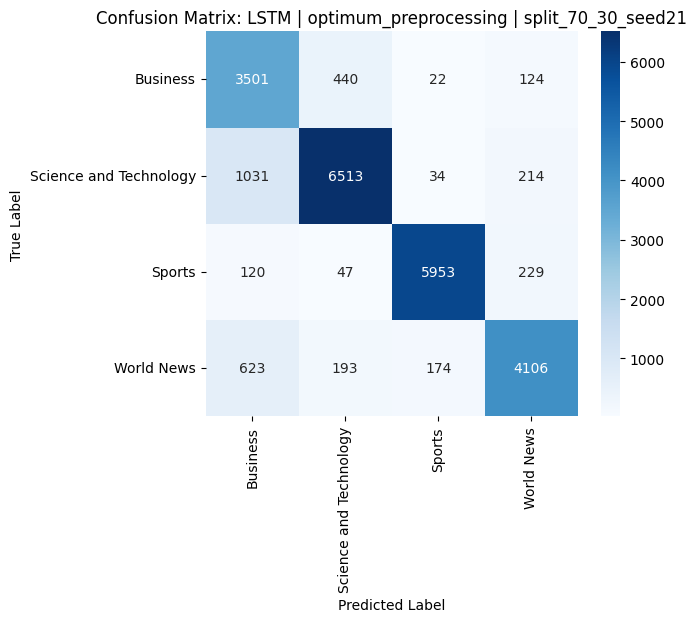

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
26,RUN_27,27,LSTM,Skip-gram Word2Vec,optimum_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.860616,0.851963,11.31,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 27: Skip-gram LSTM, optimum preprocessing
result_run_27 = run_skipgram_sequence_model('RUN_27', 27, 'LSTM', 'optimum_preprocessing', 'split_70_30_seed21', 150, 55, 12000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_27, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 28: Skip-gram Bidirectional SimpleRNN, optimum preprocessing**

Using cached Word2Vec model: optimum_preprocessing_split_80_20_seed42_100_5_2_5
SequenceClassifier(
  (embedding): Embedding(12000, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/4 - loss: 0.5036 - val_accuracy: 0.8851
Epoch 2/4 - loss: 0.3384 - val_accuracy: 0.8891
Epoch 3/4 - loss: 0.3291 - val_accuracy: 0.8928
Epoch 4/4 - loss: 0.3218 - val_accuracy: 0.8951
Run ID: RUN_28
Model: Bidirectional SimpleRNN
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_80_20_seed42
Accuracy: 0.8951
Macro F1-score: 0.8863

Classification Report:
                         precision    recall  f1-score   support

              Business       0.81      0.79      0.80      2725
Science and Technology       0.87      0.91      

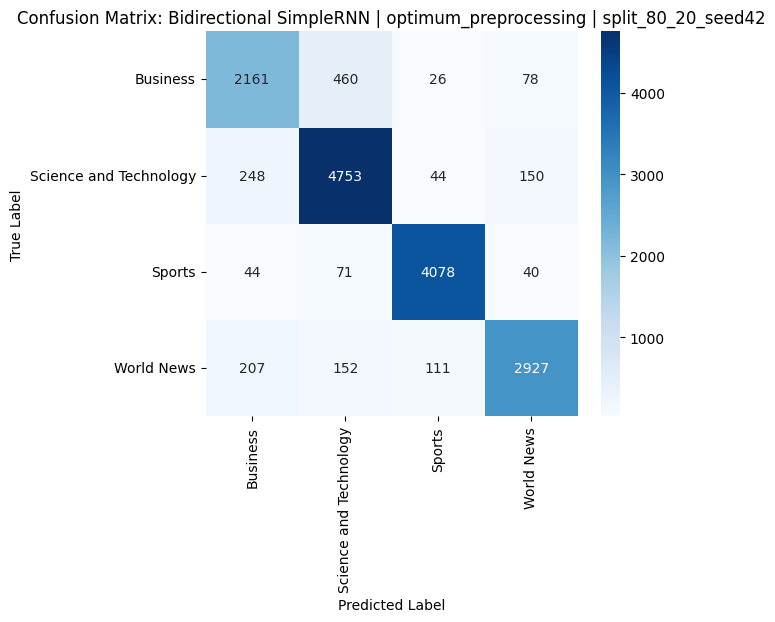

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
27,RUN_28,28,Bidirectional SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.895113,0.886314,3.47,12000.0,5.0,2.0,5.0


In [ ]:
# RUN 28: Skip-gram Bidirectional SimpleRNN, optimum preprocessing
result_run_28 = run_skipgram_sequence_model('RUN_28', 28, 'Bidirectional SimpleRNN', 'optimum_preprocessing', 'split_80_20_seed42', 100, 50, 12000, 64, 0.30, 4, 256)
experiment_results = add_or_update_result(result_run_28, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 29: Skip-gram Bidirectional GRU, optimum preprocessing**

Trained Skip-gram Word2Vec model: optimum_preprocessing_split_75_25_seed7_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): GRU(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.4732 - val_accuracy: 0.9034
Epoch 2/5 - loss: 0.2904 - val_accuracy: 0.9049
Epoch 3/5 - loss: 0.2757 - val_accuracy: 0.9087
Epoch 4/5 - loss: 0.2677 - val_accuracy: 0.9114
Epoch 5/5 - loss: 0.2610 - val_accuracy: 0.9136
Run ID: RUN_29
Model: Bidirectional GRU
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_75_25_seed7
Accuracy: 0.9136
Macro F1-score: 0.9059

Classification Report:
                         precision    recall  f1-score   support

              Business       0.85      0.82      0.83      3406
Sci

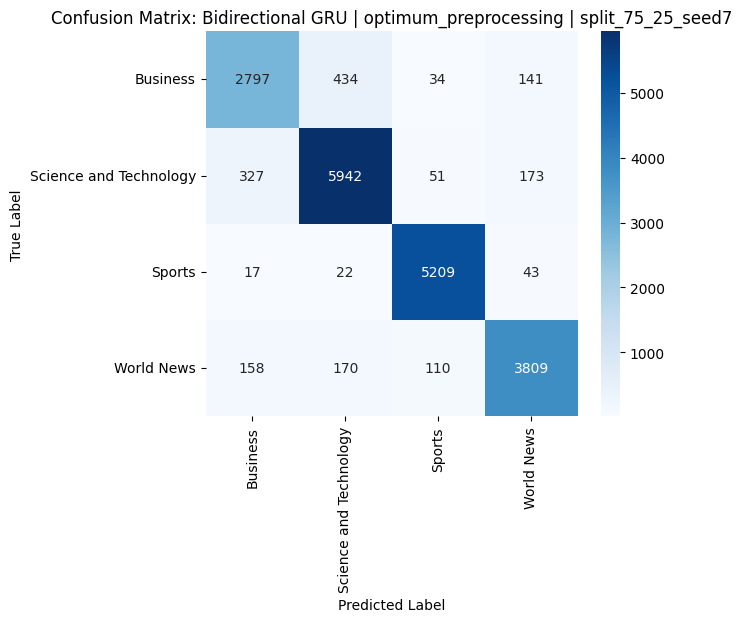

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
28,RUN_29,29,Bidirectional GRU,Skip-gram Word2Vec,optimum_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.913567,0.905948,12.28,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 29: Skip-gram Bidirectional GRU, optimum preprocessing
result_run_29 = run_skipgram_sequence_model('RUN_29', 29, 'Bidirectional GRU', 'optimum_preprocessing', 'split_75_25_seed7', 150, 55, 15000, 64, 0.35, 5, 256)
experiment_results = add_or_update_result(result_run_29, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

## **Run 30: Skip-gram Bidirectional LSTM, optimum preprocessing**

Using cached Word2Vec model: optimum_preprocessing_split_70_30_seed21_150_5_2_5
SequenceClassifier(
  (embedding): Embedding(15000, 150, padding_idx=0)
  (rnn): LSTM(150, 64, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 1/5 - loss: 0.4859 - val_accuracy: 0.8934
Epoch 2/5 - loss: 0.3032 - val_accuracy: 0.8986
Epoch 3/5 - loss: 0.2870 - val_accuracy: 0.8994
Epoch 4/5 - loss: 0.2720 - val_accuracy: 0.9032
Epoch 5/5 - loss: 0.2625 - val_accuracy: 0.9073
Run ID: RUN_30
Model: Bidirectional LSTM
Representation: Skip-gram Word2Vec
Preprocessing: optimum_preprocessing
Split: split_70_30_seed21
Accuracy: 0.9073
Macro F1-score: 0.8993

Classification Report:
                         precision    recall  f1-score   support

              Business       0.86      0.79      0.83      4087
Scien

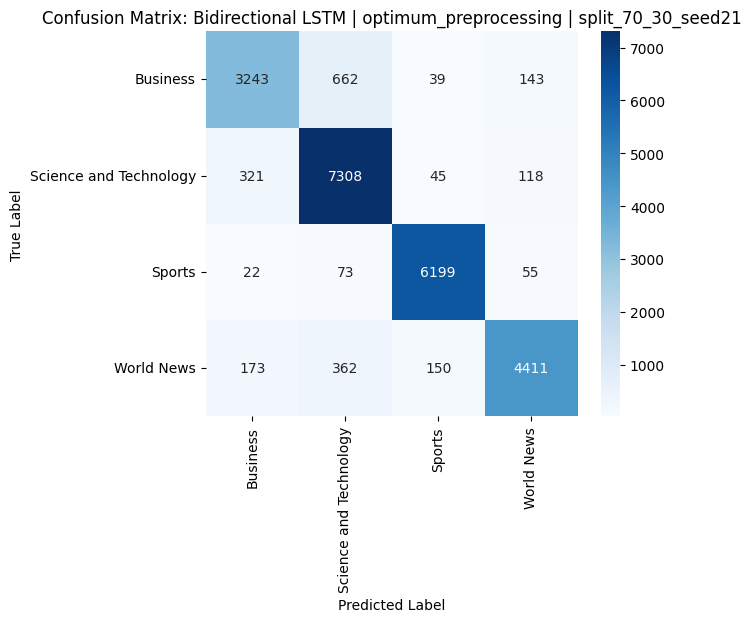

Saved log to: project_outputs\validation_experiment_log.csv


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
29,RUN_30,30,Bidirectional LSTM,Skip-gram Word2Vec,optimum_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.907263,0.899277,4.25,15000.0,5.0,2.0,5.0


In [ ]:
# RUN 30: Skip-gram Bidirectional LSTM, optimum preprocessing
result_run_30 = run_skipgram_sequence_model('RUN_30', 30, 'Bidirectional LSTM', 'optimum_preprocessing', 'split_70_30_seed21', 150, 60, 15000, 64, 0.40, 5, 256)
experiment_results = add_or_update_result(result_run_30, experiment_results)
validation_log_df = save_experiment_logs(experiment_results, "validation_experiment_log.csv")
display(validation_log_df.tail(1))

# **9. Validation Result Comparison**

In [ ]:
# Load and display the complete validation tuning log
validation_log_path = os.path.join(OUTPUT_DIR, "validation_experiment_log.csv")
validation_results_df = pd.read_csv(validation_log_path)
validation_results_df = validation_results_df.sort_values("validation_macro_f1", ascending=False)

display(validation_results_df)

,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
1,RUN_02,2,Logistic Regression,TF-IDF,no_preprocessing,split_75_25_seed7,30000.0,1.0,2.0,2.0,...,NaN,NaN,NaN,0.923394,0.917533,6.32,NaN,NaN,NaN,NaN
5,RUN_06,6,Logistic Regression,TF-IDF,optimum_preprocessing,split_75_25_seed7,30000.0,1.0,2.0,2.0,...,NaN,NaN,NaN,0.919226,0.912717,4.55,NaN,NaN,NaN,NaN
0,RUN_01,1,Logistic Regression,TF-IDF,no_preprocessing,split_80_20_seed42,20000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,0.918457,0.911588,3.09,NaN,NaN,NaN,NaN
6,RUN_07,7,Deep Neural Network,TF-IDF,no_preprocessing,split_80_20_seed42,8000.0,1.0,1.0,NaN,...,NaN,NaN,NaN,0.917942,0.911011,6.41,NaN,NaN,NaN,NaN
7,RUN_08,8,Deep Neural Network,TF-IDF,no_preprocessing,split_75_25_seed7,10000.0,1.0,2.0,NaN,...,NaN,NaN,NaN,0.915265,0.909280,9.53,NaN,NaN,NaN,NaN
11,RUN_12,12,Deep Neural Network,TF-IDF,optimum_preprocessing,split_75_25_seed7,10000.0,1.0,2.0,NaN,...,NaN,NaN,NaN,0.915470,0.909074,7.94,NaN,NaN,NaN,NaN
3,RUN_04,4,Logistic Regression,TF-IDF,extreme_preprocessing,split_70_30_seed21,30000.0,1.0,2.0,2.0,...,NaN,NaN,NaN,0.915966,0.908545,4.96,NaN,NaN,NaN,NaN
4,RUN_05,5,Logistic Regression,TF-IDF,optimum_preprocessing,split_80_20_seed42,20000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,0.914084,0.906513,2.17,NaN,NaN,NaN,NaN
9,RUN_10,10,Deep Neural Network,TF-IDF,extreme_preprocessing,split_70_30_seed21,10000.0,1.0,2.0,NaN,...,NaN,NaN,NaN,0.913823,0.906126,7.63,NaN,NaN,NaN,NaN
28,RUN_29,29,Bidirectional GRU,Skip-gram Word2Vec,optimum_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.913567,0.905948,12.28,15000.0,5.0,2.0,5.0


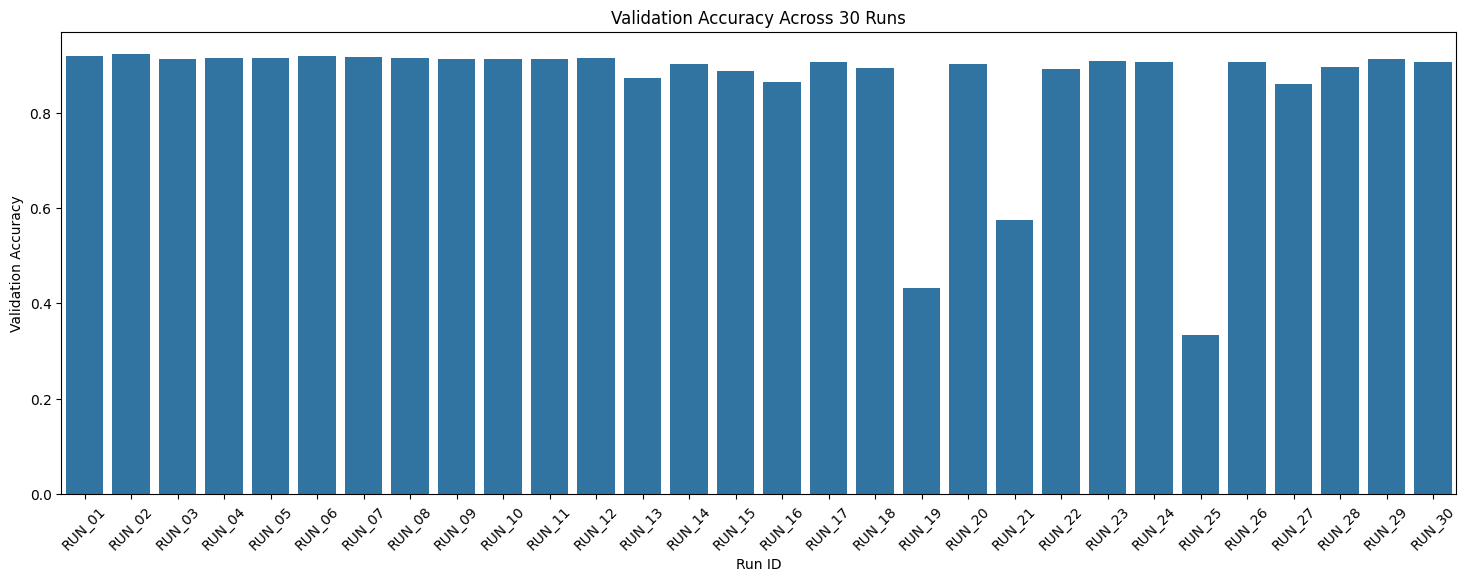

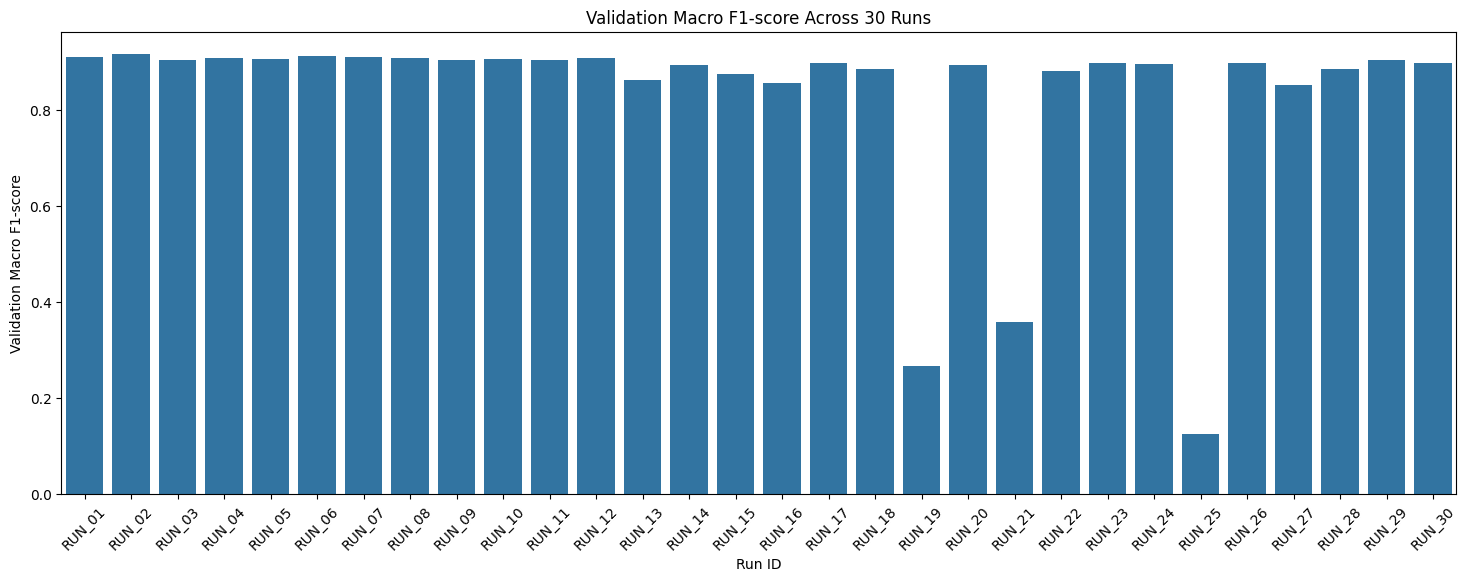

In [ ]:
# Plot validation accuracy and macro F1-score for all 30 runs
plot_df = validation_results_df.sort_values("run_number")
plot_df["run_label"] = plot_df["run_id"] + "\n" + plot_df["model"] + "\n" + plot_df["preprocessing"]

plt.figure(figsize=(18, 6))
sns.barplot(data=plot_df, x="run_id", y="validation_accuracy")
plt.title("Validation Accuracy Across 30 Runs")
plt.xlabel("Run ID")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(18, 6))
sns.barplot(data=plot_df, x="run_id", y="validation_macro_f1")
plt.title("Validation Macro F1-score Across 30 Runs")
plt.xlabel("Run ID")
plt.ylabel("Validation Macro F1-score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Identify the best and worst validation experiments
best_validation = validation_results_df.iloc[0]
worst_validation = validation_results_df.iloc[-1]

print("Best validation experiment:")
display(best_validation.to_frame().T)
print("Worst validation experiment:")
display(worst_validation.to_frame().T)

Best validation experiment:


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
1,RUN_02,2,Logistic Regression,TF-IDF,no_preprocessing,split_75_25_seed7,30000.0,1.0,2.0,2.0,...,NaN,NaN,NaN,0.923394,0.917533,6.32,NaN,NaN,NaN,NaN


Worst validation experiment:


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
24,RUN_25,25,SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,45.0,64.0,0.334084,0.125211,9.12,10000.0,5.0,2.0,5.0


In [ ]:
# Select the best validation configuration for each model and preprocessing pair
selected_validation_configs = (
    validation_results_df
    .sort_values("validation_macro_f1", ascending=False)
    .groupby(["model", "representation", "preprocessing"], as_index=False)
    .head(1)
    .sort_values(["representation", "model", "preprocessing"])
    .reset_index(drop=True)
)

print("Selected configurations for final test evaluation:")
display(selected_validation_configs)

Selected configurations for final test evaluation:


,run_id,run_number,model,representation,preprocessing,split_name,max_features,ngram_min,ngram_max,C,...,embedding_dim,max_len,rnn_units,validation_accuracy,validation_macro_f1,runtime_seconds,num_words,window,min_count,word2vec_epochs
0,RUN_23,23,Bidirectional GRU,Skip-gram Word2Vec,extreme_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.907908,0.898825,12.01,15000.0,5.0,2.0,5.0
1,RUN_17,17,Bidirectional GRU,Skip-gram Word2Vec,no_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.907033,0.899355,17.04,15000.0,5.0,2.0,5.0
2,RUN_29,29,Bidirectional GRU,Skip-gram Word2Vec,optimum_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,150.0,55.0,64.0,0.913567,0.905948,12.28,15000.0,5.0,2.0,5.0
3,RUN_24,24,Bidirectional LSTM,Skip-gram Word2Vec,extreme_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.905891,0.896407,4.23,15000.0,5.0,2.0,5.0
4,RUN_18,18,Bidirectional LSTM,Skip-gram Word2Vec,no_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.894958,0.885588,4.49,15000.0,5.0,2.0,5.0
5,RUN_30,30,Bidirectional LSTM,Skip-gram Word2Vec,optimum_preprocessing,split_70_30_seed21,NaN,NaN,NaN,NaN,...,150.0,60.0,64.0,0.907263,0.899277,4.25,15000.0,5.0,2.0,5.0
6,RUN_22,22,Bidirectional SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.891383,0.881558,3.47,12000.0,5.0,2.0,5.0
7,RUN_16,16,Bidirectional SimpleRNN,Skip-gram Word2Vec,no_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.865659,0.856931,3.88,12000.0,5.0,2.0,5.0
8,RUN_28,28,Bidirectional SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,split_80_20_seed42,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.895113,0.886314,3.47,12000.0,5.0,2.0,5.0
9,RUN_20,20,GRU,Skip-gram Word2Vec,extreme_preprocessing,split_75_25_seed7,NaN,NaN,NaN,NaN,...,100.0,50.0,64.0,0.902557,0.894545,8.89,12000.0,5.0,2.0,5.0


# **10. Final Test Evaluation**

In [ ]:
# Define final test functions for selected validation configurations

def evaluate_final_tfidf_lr(config_row):
    start_time = time.time()
    preprocessing_col = config_row["preprocessing"]
    vectorizer = TfidfVectorizer(max_features=int(config_row["max_features"]), ngram_range=(int(config_row["ngram_min"]), int(config_row["ngram_max"])), min_df=2, max_df=0.95)
    X_train_tfidf = vectorizer.fit_transform(processed_train_df[preprocessing_col].astype(str))
    X_test_tfidf = vectorizer.transform(processed_test_df[preprocessing_col].astype(str))
    y_train = processed_train_df["label"].values
    y_test = processed_test_df["label"].values
    model = LogisticRegression(C=float(config_row["C"]), max_iter=int(config_row["max_iter"]), solver="lbfgs", random_state=SEED)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)
    print("Final test result for:", config_row["run_id"], config_row["model"], preprocessing_col)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1-score:", round(macro_f1, 4))
    print(report)
    plot_confusion_matrix(cm, f"Final Confusion Matrix: {config_row['model']} | {preprocessing_col}")
    return {"source_run_id": config_row["run_id"], "model": config_row["model"], "representation": config_row["representation"], "preprocessing": preprocessing_col, "test_accuracy": accuracy, "test_macro_f1": macro_f1, "runtime_seconds": round(time.time() - start_time, 2)}

def evaluate_final_tfidf_dnn(config_row):
    start_time = time.time()
    preprocessing_col = config_row["preprocessing"]
    vectorizer = TfidfVectorizer(max_features=int(config_row["max_features"]), ngram_range=(int(config_row["ngram_min"]), int(config_row["ngram_max"])), min_df=2, max_df=0.95)
    X_train_tfidf = vectorizer.fit_transform(processed_train_df[preprocessing_col].astype(str))
    X_test_tfidf = vectorizer.transform(processed_test_df[preprocessing_col].astype(str))
    y_train = processed_train_df["label"].values
    y_test = processed_test_df["label"].values
    X_train_dense = scipy_sparse_to_torch_dense(X_train_tfidf)
    X_test_dense = scipy_sparse_to_torch_dense(X_test_tfidf)
    model = build_tfidf_dnn(X_train_tfidf.shape[1], int(config_row["hidden_units"]), float(config_row["dropout"]))
    train_torch_classifier(model, X_train_dense, y_train, epochs=int(config_row["epochs"]), batch_size=int(config_row["batch_size"]), is_sequence=False, verbose=1)
    y_pred = predict_torch_classifier(model, X_test_dense, batch_size=int(config_row["batch_size"]), is_sequence=False)
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)
    print("Final test result for:", config_row["run_id"], config_row["model"], preprocessing_col)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1-score:", round(macro_f1, 4))
    print(report)
    plot_confusion_matrix(cm, f"Final Confusion Matrix: {config_row['model']} | {preprocessing_col}")
    return {"source_run_id": config_row["run_id"], "model": config_row["model"], "representation": config_row["representation"], "preprocessing": preprocessing_col, "test_accuracy": accuracy, "test_macro_f1": macro_f1, "runtime_seconds": round(time.time() - start_time, 2)}


In [ ]:
# Define final test function for selected Skip-gram sequence configurations

def prepare_final_sequence_data(preprocessing_col, num_words, max_len, embedding_dim, window, min_count, word2vec_epochs):
    tokenizer = SimpleTokenizer(num_words=num_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(processed_train_df[preprocessing_col].astype(str))
    X_train_seq = tokenizer.texts_to_sequences(processed_train_df[preprocessing_col].astype(str))
    X_test_seq = tokenizer.texts_to_sequences(processed_test_df[preprocessing_col].astype(str))
    X_train_pad = pad_sequences_custom(X_train_seq, maxlen=max_len, padding="post", truncating="post")
    X_test_pad = pad_sequences_custom(X_test_seq, maxlen=max_len, padding="post", truncating="post")
    tokenized_sentences = simple_tokenize_for_word2vec(processed_train_df[preprocessing_col])
    word2vec_model = Word2Vec(sentences=tokenized_sentences, vector_size=embedding_dim, window=window, min_count=min_count, workers=4, sg=1, epochs=word2vec_epochs, seed=SEED)
    vocab_size = min(num_words, len(tokenizer.word_index) + 1)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
    for word, index in tokenizer.word_index.items():
        if index < vocab_size and word in word2vec_model.wv:
            embedding_matrix[index] = word2vec_model.wv[word]
    return X_train_pad, X_test_pad, processed_train_df["label"].values, processed_test_df["label"].values, embedding_matrix

def evaluate_final_skipgram_sequence(config_row):
    start_time = time.time()
    preprocessing_col = config_row["preprocessing"]
    X_train_pad, X_test_pad, y_train, y_test, embedding_matrix = prepare_final_sequence_data(
        preprocessing_col,
        int(config_row["num_words"]),
        int(config_row["max_len"]),
        int(config_row["embedding_dim"]),
        int(config_row["window"]),
        int(config_row["min_count"]),
        int(config_row["word2vec_epochs"])
    )
    model = build_sequence_model(config_row["model"], embedding_matrix, int(config_row["max_len"]), int(config_row["rnn_units"]), float(config_row["dropout"]))
    train_torch_classifier(model, X_train_pad, y_train, epochs=int(config_row["epochs"]), batch_size=int(config_row["batch_size"]), is_sequence=True, verbose=1)
    y_pred = predict_torch_classifier(model, X_test_pad, batch_size=int(config_row["batch_size"]), is_sequence=True)
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)
    print("Final test result for:", config_row["run_id"], config_row["model"], preprocessing_col)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1-score:", round(macro_f1, 4))
    print(report)
    plot_confusion_matrix(cm, f"Final Confusion Matrix: {config_row['model']} | {preprocessing_col}")
    return {"source_run_id": config_row["run_id"], "model": config_row["model"], "representation": config_row["representation"], "preprocessing": preprocessing_col, "test_accuracy": accuracy, "test_macro_f1": macro_f1, "runtime_seconds": round(time.time() - start_time, 2)}


Epoch 1/5 - loss: 0.4273
Epoch 2/5 - loss: 0.2783
Epoch 3/5 - loss: 0.2643
Epoch 4/5 - loss: 0.2568
Epoch 5/5 - loss: 0.2467
Final test result for: RUN_23 Bidirectional GRU extreme_preprocessing
Accuracy: 0.9019
Macro F1-score: 0.9017
                        precision    recall  f1-score   support

              Business       0.91      0.81      0.86      3000
Science and Technology       0.81      0.95      0.87      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.96      0.86      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.91      0.90      0.90     12000
          weighted avg       0.91      0.90      0.90     12000



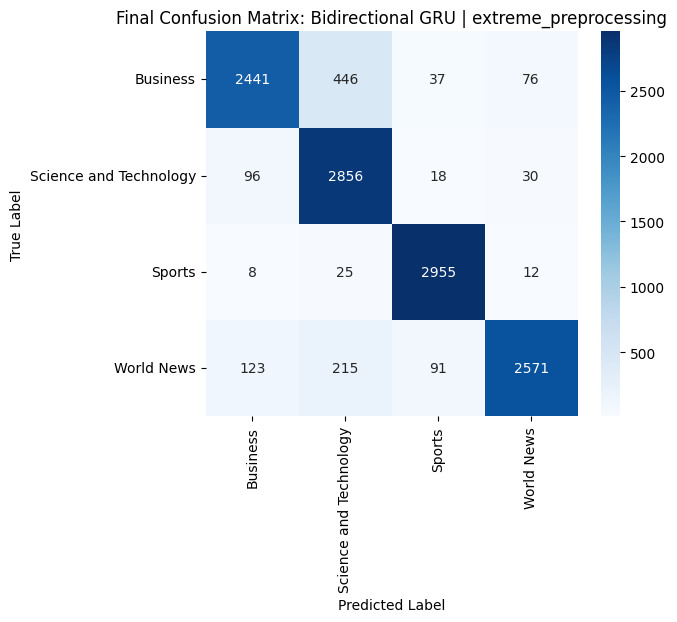

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
0,RUN_23,Bidirectional GRU,Skip-gram Word2Vec,extreme_preprocessing,0.901917,0.901749,14.78


Epoch 1/5 - loss: 0.5406
Epoch 2/5 - loss: 0.2991
Epoch 3/5 - loss: 0.2800
Epoch 4/5 - loss: 0.2673
Epoch 5/5 - loss: 0.2585
Final test result for: RUN_17 Bidirectional GRU no_preprocessing
Accuracy: 0.9
Macro F1-score: 0.8996
                        precision    recall  f1-score   support

              Business       0.93      0.79      0.85      3000
Science and Technology       0.81      0.95      0.87      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.92      0.89      0.91      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



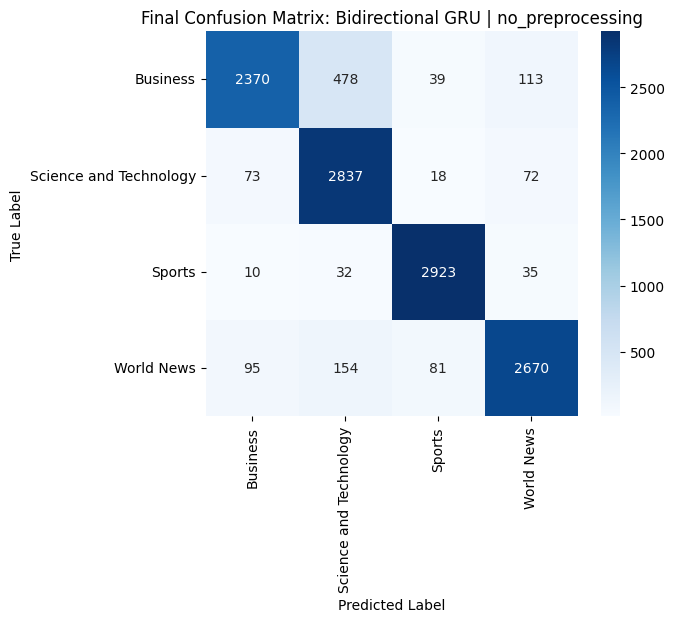

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
1,RUN_17,Bidirectional GRU,Skip-gram Word2Vec,no_preprocessing,0.9,0.899575,21.99


Epoch 1/5 - loss: 0.4233
Epoch 2/5 - loss: 0.2786
Epoch 3/5 - loss: 0.2652
Epoch 4/5 - loss: 0.2550
Epoch 5/5 - loss: 0.2470
Final test result for: RUN_29 Bidirectional GRU optimum_preprocessing
Accuracy: 0.9047
Macro F1-score: 0.904
                        precision    recall  f1-score   support

              Business       0.92      0.80      0.86      3000
Science and Technology       0.83      0.95      0.88      3000
                Sports       0.95      0.99      0.97      3000
            World News       0.94      0.89      0.91      3000

              accuracy                           0.90     12000
             macro avg       0.91      0.90      0.90     12000
          weighted avg       0.91      0.90      0.90     12000



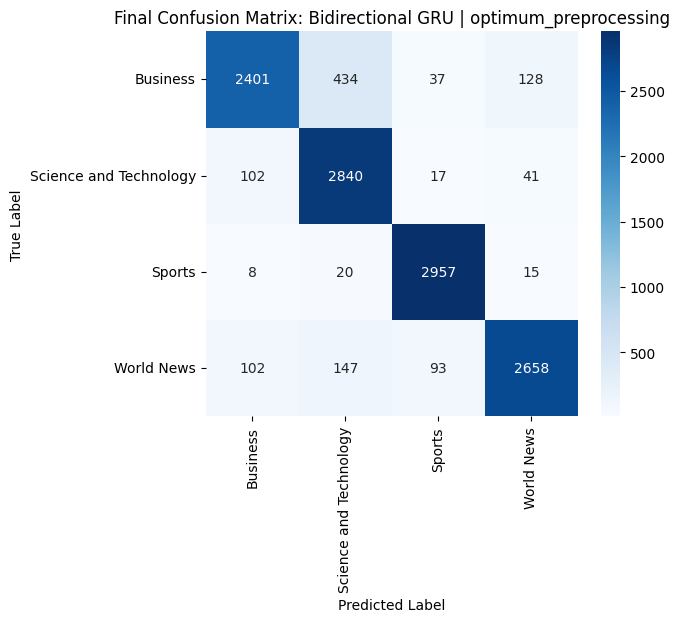

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
2,RUN_29,Bidirectional GRU,Skip-gram Word2Vec,optimum_preprocessing,0.904667,0.90405,14.7


Epoch 1/5 - loss: 0.4401
Epoch 2/5 - loss: 0.2917
Epoch 3/5 - loss: 0.2724
Epoch 4/5 - loss: 0.2616
Epoch 5/5 - loss: 0.2535
Final test result for: RUN_24 Bidirectional LSTM extreme_preprocessing
Accuracy: 0.907
Macro F1-score: 0.9064
                        precision    recall  f1-score   support

              Business       0.92      0.81      0.86      3000
Science and Technology       0.84      0.94      0.89      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.93      0.90      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



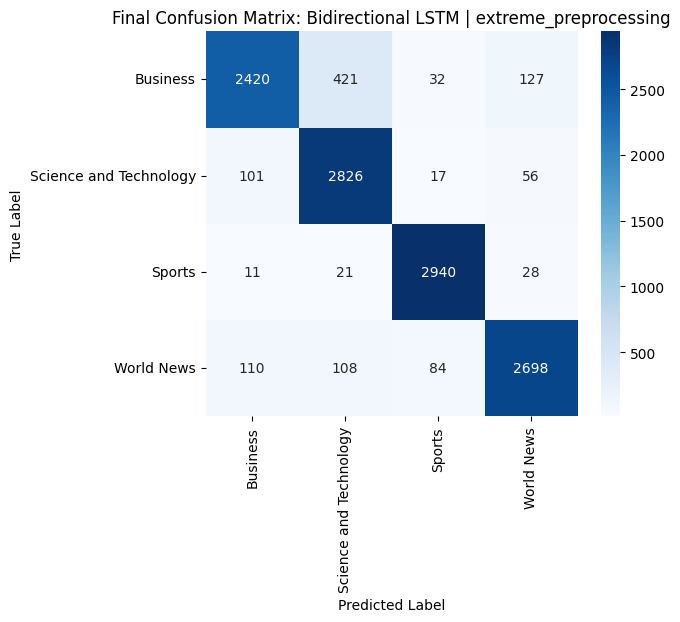

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
3,RUN_24,Bidirectional LSTM,Skip-gram Word2Vec,extreme_preprocessing,0.907,0.906426,14.66


Epoch 1/5 - loss: 0.5638
Epoch 2/5 - loss: 0.3261
Epoch 3/5 - loss: 0.2989
Epoch 4/5 - loss: 0.2837
Epoch 5/5 - loss: 0.2729
Final test result for: RUN_18 Bidirectional LSTM no_preprocessing
Accuracy: 0.8922
Macro F1-score: 0.8912
                        precision    recall  f1-score   support

              Business       0.94      0.76      0.84      3000
Science and Technology       0.81      0.93      0.87      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.89      0.91      0.90      3000

              accuracy                           0.89     12000
             macro avg       0.90      0.89      0.89     12000
          weighted avg       0.90      0.89      0.89     12000



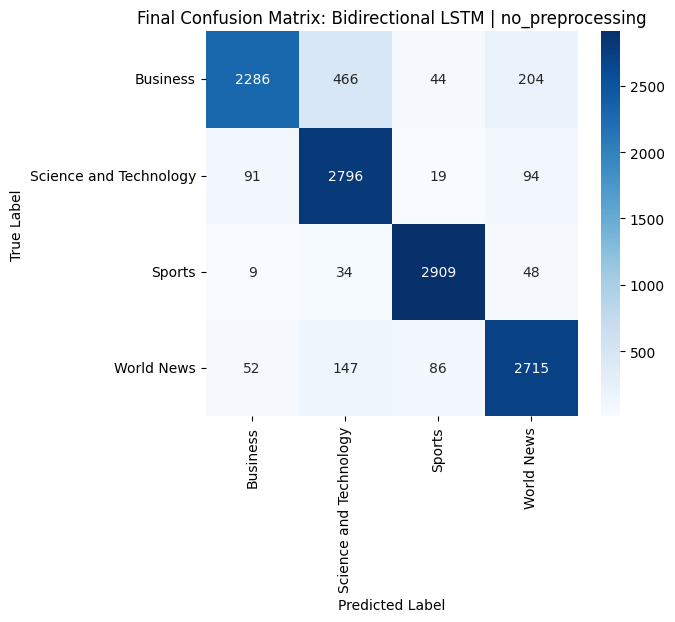

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
4,RUN_18,Bidirectional LSTM,Skip-gram Word2Vec,no_preprocessing,0.892167,0.891236,22.04


Epoch 1/5 - loss: 0.4287
Epoch 2/5 - loss: 0.2870
Epoch 3/5 - loss: 0.2728
Epoch 4/5 - loss: 0.2612
Epoch 5/5 - loss: 0.2516
Final test result for: RUN_30 Bidirectional LSTM optimum_preprocessing
Accuracy: 0.9061
Macro F1-score: 0.9059
                        precision    recall  f1-score   support

              Business       0.91      0.82      0.86      3000
Science and Technology       0.83      0.95      0.88      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.94      0.88      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



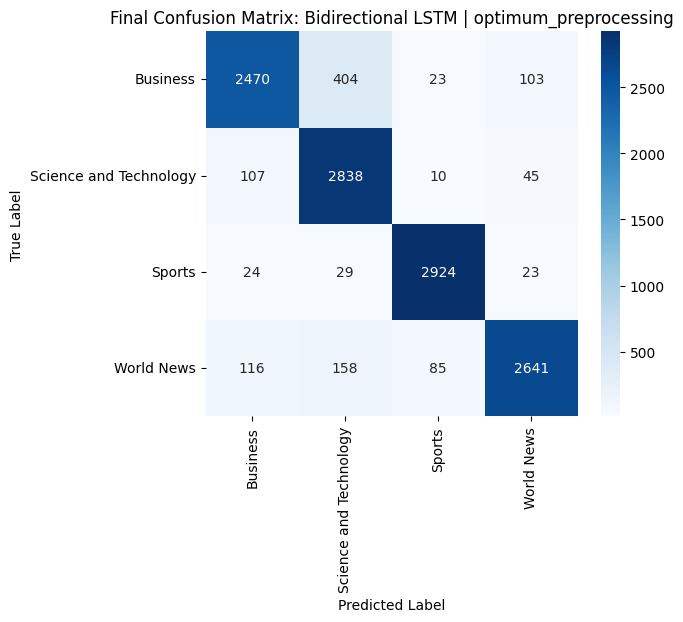

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
5,RUN_30,Bidirectional LSTM,Skip-gram Word2Vec,optimum_preprocessing,0.906083,0.905916,14.85


Epoch 1/4 - loss: 0.4540
Epoch 2/4 - loss: 0.3295
Epoch 3/4 - loss: 0.3213
Epoch 4/4 - loss: 0.3149
Final test result for: RUN_22 Bidirectional SimpleRNN extreme_preprocessing
Accuracy: 0.8938
Macro F1-score: 0.8934
                        precision    recall  f1-score   support

              Business       0.88      0.82      0.85      3000
Science and Technology       0.85      0.89      0.87      3000
                Sports       0.94      0.97      0.96      3000
            World News       0.91      0.89      0.90      3000

              accuracy                           0.89     12000
             macro avg       0.89      0.89      0.89     12000
          weighted avg       0.89      0.89      0.89     12000



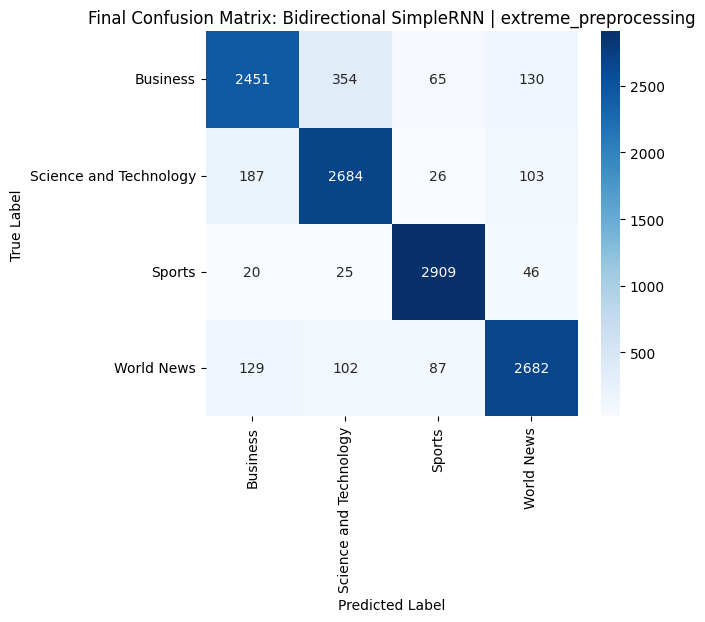

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
6,RUN_22,Bidirectional SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,0.893833,0.893362,11.32


Epoch 1/4 - loss: 0.8572
Epoch 2/4 - loss: 0.4975
Epoch 3/4 - loss: 0.4236
Epoch 4/4 - loss: 0.3850
Final test result for: RUN_16 Bidirectional SimpleRNN no_preprocessing
Accuracy: 0.495
Macro F1-score: 0.3825
                        precision    recall  f1-score   support

              Business       0.00      0.00      0.00      3000
Science and Technology       0.34      0.98      0.50      3000
                Sports       0.93      0.95      0.94      3000
            World News       0.83      0.05      0.09      3000

              accuracy                           0.49     12000
             macro avg       0.52      0.49      0.38     12000
          weighted avg       0.52      0.49      0.38     12000



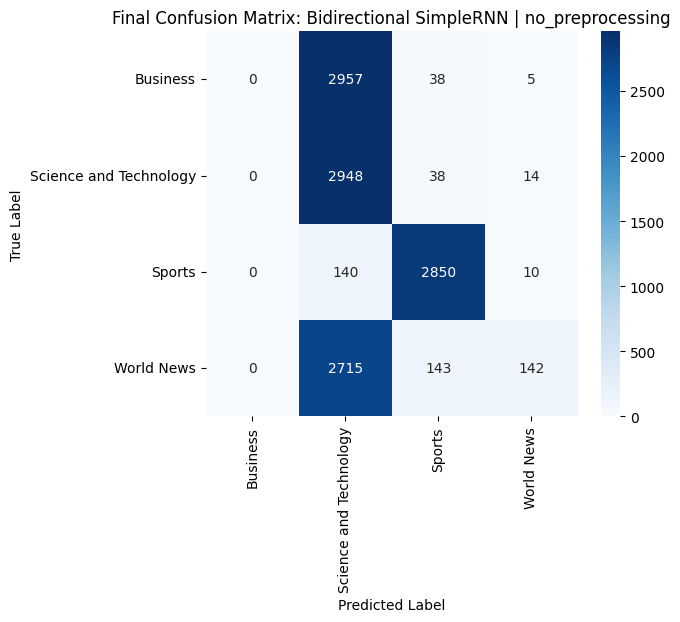

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
7,RUN_16,Bidirectional SimpleRNN,Skip-gram Word2Vec,no_preprocessing,0.495,0.38253,17.36


Epoch 1/4 - loss: 0.4591
Epoch 2/4 - loss: 0.3341
Epoch 3/4 - loss: 0.3242
Epoch 4/4 - loss: 0.3187
Final test result for: RUN_28 Bidirectional SimpleRNN optimum_preprocessing
Accuracy: 0.888
Macro F1-score: 0.8878
                        precision    recall  f1-score   support

              Business       0.85      0.85      0.85      3000
Science and Technology       0.82      0.91      0.87      3000
                Sports       0.94      0.98      0.96      3000
            World News       0.96      0.81      0.88      3000

              accuracy                           0.89     12000
             macro avg       0.89      0.89      0.89     12000
          weighted avg       0.89      0.89      0.89     12000



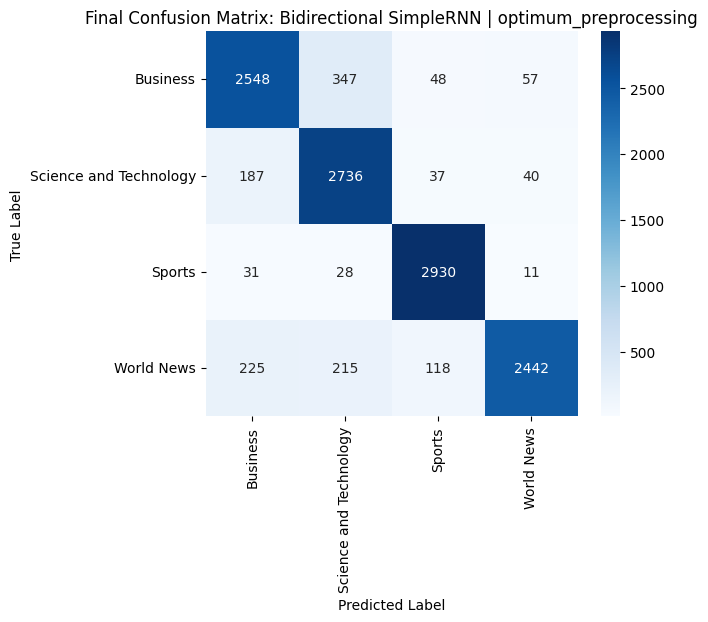

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
8,RUN_28,Bidirectional SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,0.888,0.887774,11.49


Epoch 1/4 - loss: 0.9260
Epoch 2/4 - loss: 0.3175
Epoch 3/4 - loss: 0.2911
Epoch 4/4 - loss: 0.2779
Final test result for: RUN_20 GRU extreme_preprocessing
Accuracy: 0.9047
Macro F1-score: 0.9042
                        precision    recall  f1-score   support

              Business       0.89      0.84      0.86      3000
Science and Technology       0.85      0.91      0.88      3000
                Sports       0.94      0.99      0.96      3000
            World News       0.94      0.88      0.91      3000

              accuracy                           0.90     12000
             macro avg       0.91      0.90      0.90     12000
          weighted avg       0.91      0.90      0.90     12000



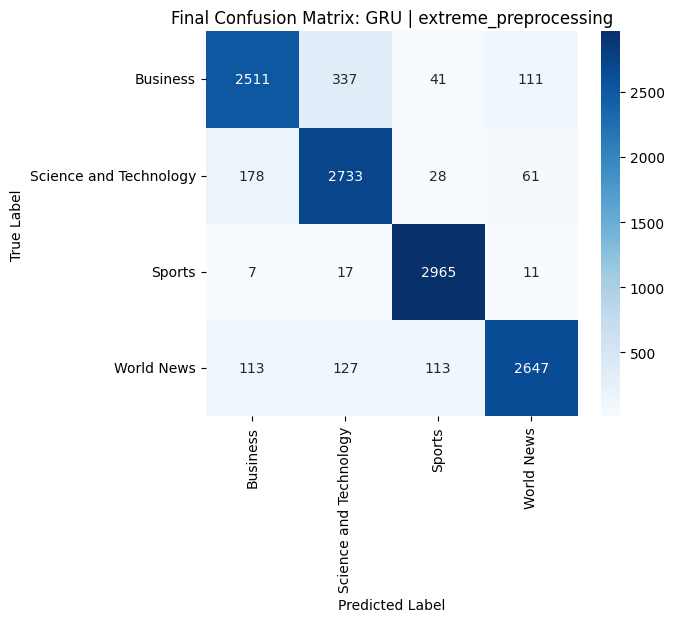

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
9,RUN_20,GRU,Skip-gram Word2Vec,extreme_preprocessing,0.904667,0.904227,11.02


Epoch 1/4 - loss: 0.6007
Epoch 2/4 - loss: 0.3155
Epoch 3/4 - loss: 0.2921
Epoch 4/4 - loss: 0.2795
Final test result for: RUN_14 GRU no_preprocessing
Accuracy: 0.8985
Macro F1-score: 0.8984
                        precision    recall  f1-score   support

              Business       0.88      0.83      0.86      3000
Science and Technology       0.83      0.92      0.87      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.93      0.87      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



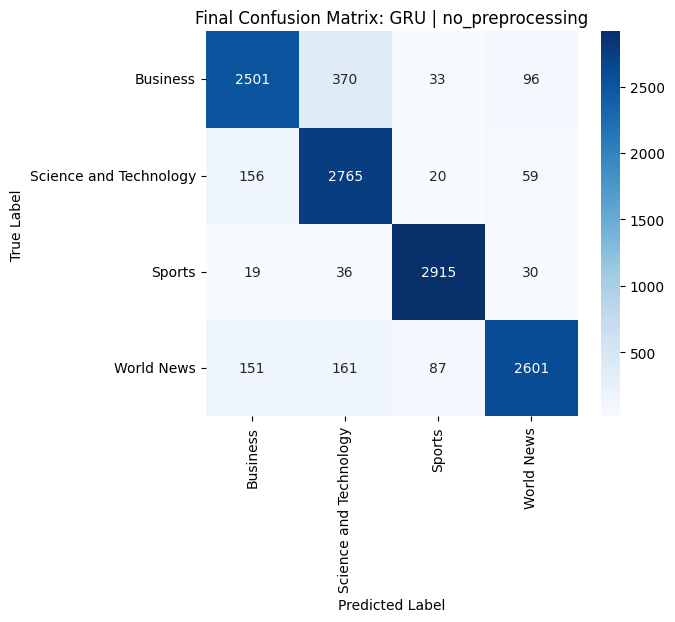

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
10,RUN_14,GRU,Skip-gram Word2Vec,no_preprocessing,0.8985,0.898417,16.92


Epoch 1/4 - loss: 0.8980
Epoch 2/4 - loss: 0.3245
Epoch 3/4 - loss: 0.2880
Epoch 4/4 - loss: 0.2743
Final test result for: RUN_26 GRU optimum_preprocessing
Accuracy: 0.9004
Macro F1-score: 0.9001
                        precision    recall  f1-score   support

              Business       0.90      0.81      0.85      3000
Science and Technology       0.82      0.94      0.87      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.94      0.87      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



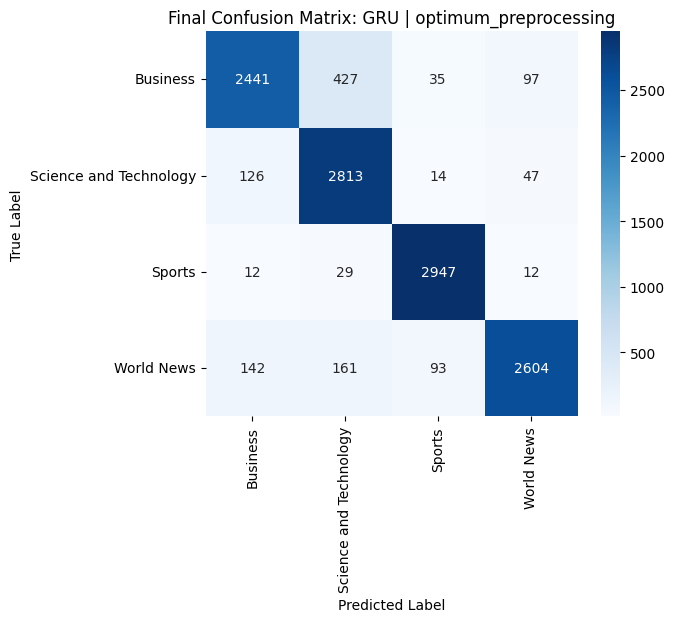

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
11,RUN_26,GRU,Skip-gram Word2Vec,optimum_preprocessing,0.900417,0.900113,11.13


Epoch 1/5 - loss: 1.1711
Epoch 2/5 - loss: 0.4396
Epoch 3/5 - loss: 0.3337
Epoch 4/5 - loss: 0.3022
Epoch 5/5 - loss: 0.2876
Final test result for: RUN_21 LSTM extreme_preprocessing
Accuracy: 0.8984
Macro F1-score: 0.8984
                        precision    recall  f1-score   support

              Business       0.89      0.84      0.86      3000
Science and Technology       0.82      0.92      0.87      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.95      0.85      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



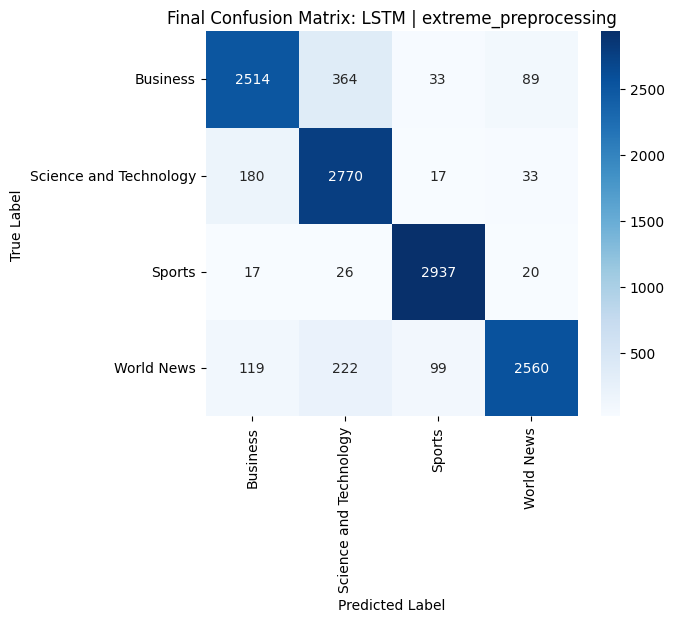

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
12,RUN_21,LSTM,Skip-gram Word2Vec,extreme_preprocessing,0.898417,0.8984,14.37


Epoch 1/5 - loss: 0.7464
Epoch 2/5 - loss: 0.3647
Epoch 3/5 - loss: 0.3261
Epoch 4/5 - loss: 0.3047
Epoch 5/5 - loss: 0.2888
Final test result for: RUN_15 LSTM no_preprocessing
Accuracy: 0.8939
Macro F1-score: 0.8937
                        precision    recall  f1-score   support

              Business       0.90      0.81      0.85      3000
Science and Technology       0.80      0.93      0.86      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.94      0.86      0.90      3000

              accuracy                           0.89     12000
             macro avg       0.90      0.89      0.89     12000
          weighted avg       0.90      0.89      0.89     12000



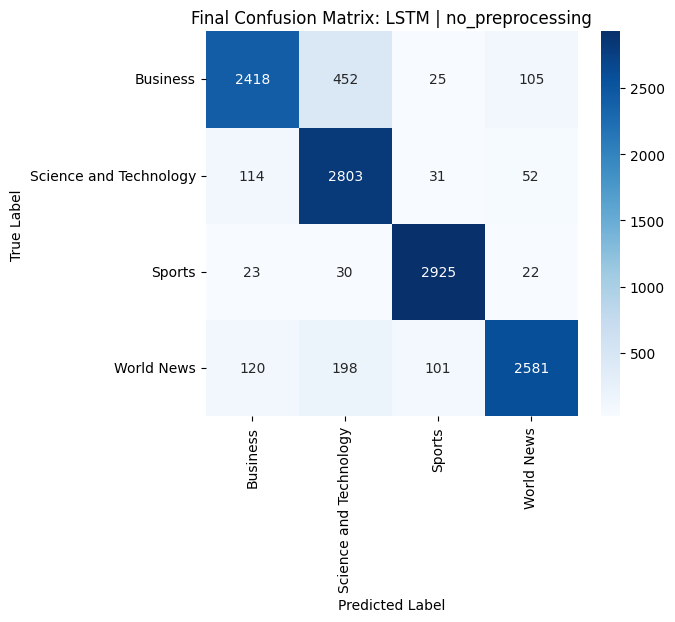

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
13,RUN_15,LSTM,Skip-gram Word2Vec,no_preprocessing,0.893917,0.893729,21.56


Epoch 1/5 - loss: 1.1912
Epoch 2/5 - loss: 1.1485
Epoch 3/5 - loss: 0.8565
Epoch 4/5 - loss: 0.5460
Epoch 5/5 - loss: 0.4310
Final test result for: RUN_27 LSTM optimum_preprocessing
Accuracy: 0.8773
Macro F1-score: 0.8763
                        precision    recall  f1-score   support

              Business       0.86      0.77      0.81      3000
Science and Technology       0.83      0.89      0.86      3000
                Sports       0.93      0.97      0.95      3000
            World News       0.89      0.88      0.88      3000

              accuracy                           0.88     12000
             macro avg       0.88      0.88      0.88     12000
          weighted avg       0.88      0.88      0.88     12000



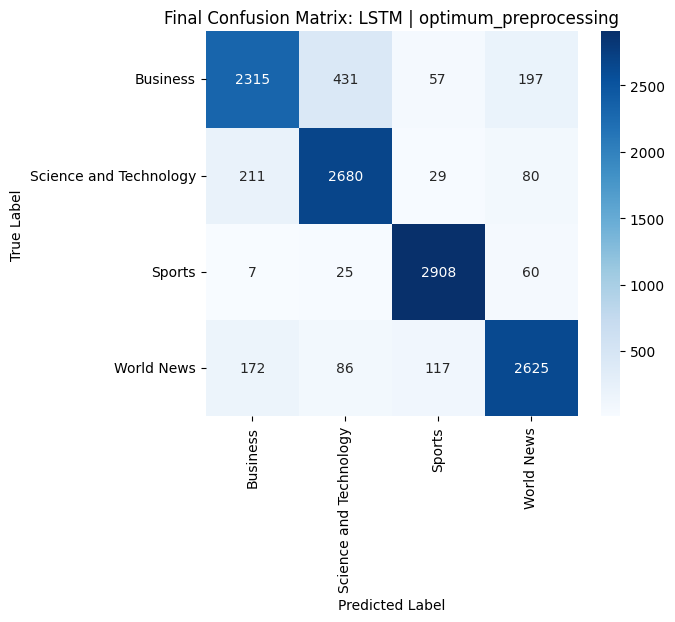

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
14,RUN_27,LSTM,Skip-gram Word2Vec,optimum_preprocessing,0.877333,0.876333,15.01


Epoch 1/4 - loss: 1.3580
Epoch 2/4 - loss: 1.3580
Epoch 3/4 - loss: 1.3561
Epoch 4/4 - loss: 1.3554
Final test result for: RUN_19 SimpleRNN extreme_preprocessing
Accuracy: 0.2502
Macro F1-score: 0.1003
                        precision    recall  f1-score   support

              Business       0.00      0.00      0.00      3000
Science and Technology       0.25      1.00      0.40      3000
                Sports       0.00      0.00      0.00      3000
            World News       1.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.31      0.25      0.10     12000
          weighted avg       0.31      0.25      0.10     12000



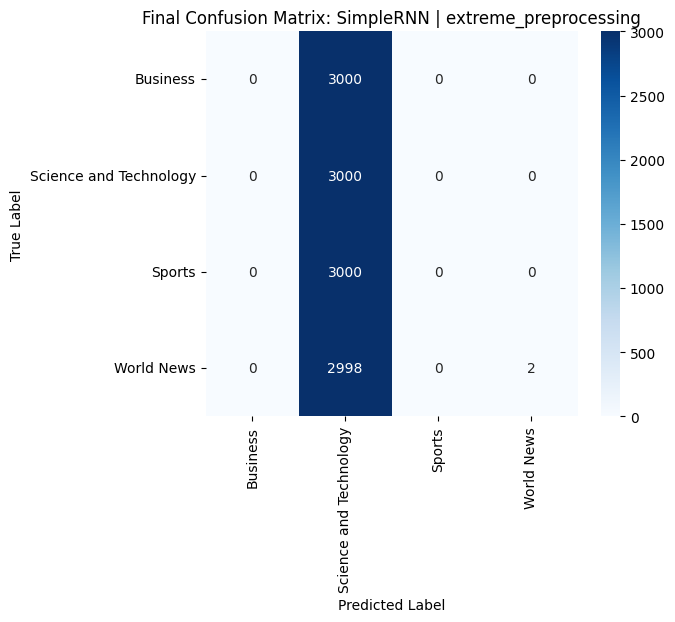

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
15,RUN_19,SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,0.250167,0.100346,11.26


Epoch 1/4 - loss: 0.7203
Epoch 2/4 - loss: 0.5034
Epoch 3/4 - loss: 0.4757
Epoch 4/4 - loss: 0.4383
Final test result for: RUN_13 SimpleRNN no_preprocessing
Accuracy: 0.8602
Macro F1-score: 0.8605
                        precision    recall  f1-score   support

              Business       0.85      0.78      0.82      3000
Science and Technology       0.77      0.90      0.83      3000
                Sports       0.95      0.93      0.94      3000
            World News       0.89      0.82      0.85      3000

              accuracy                           0.86     12000
             macro avg       0.86      0.86      0.86     12000
          weighted avg       0.86      0.86      0.86     12000



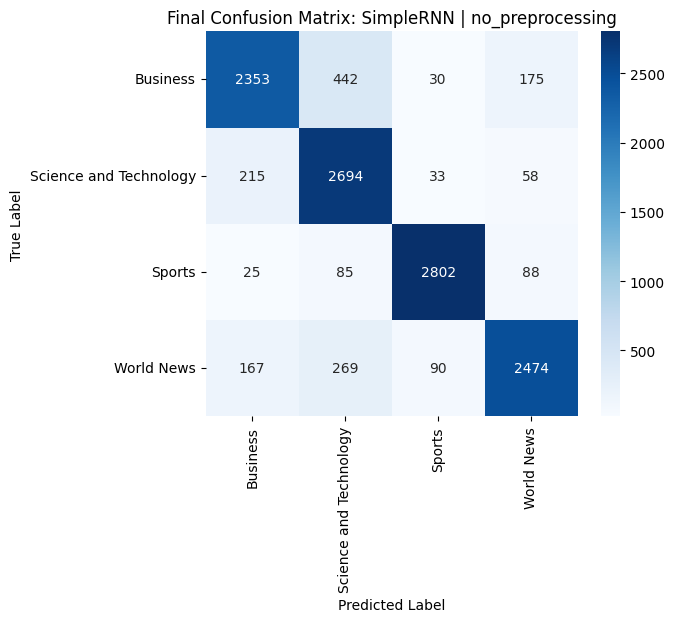

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
16,RUN_13,SimpleRNN,Skip-gram Word2Vec,no_preprocessing,0.86025,0.860528,17.33


Epoch 1/4 - loss: 1.2623
Epoch 2/4 - loss: 1.1791
Epoch 3/4 - loss: 1.3499
Epoch 4/4 - loss: 1.2959
Final test result for: RUN_25 SimpleRNN optimum_preprocessing
Accuracy: 0.2503
Macro F1-score: 0.1007
                        precision    recall  f1-score   support

              Business       0.00      0.00      0.00      3000
Science and Technology       0.25      1.00      0.40      3000
                Sports       0.80      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.26      0.25      0.10     12000
          weighted avg       0.26      0.25      0.10     12000



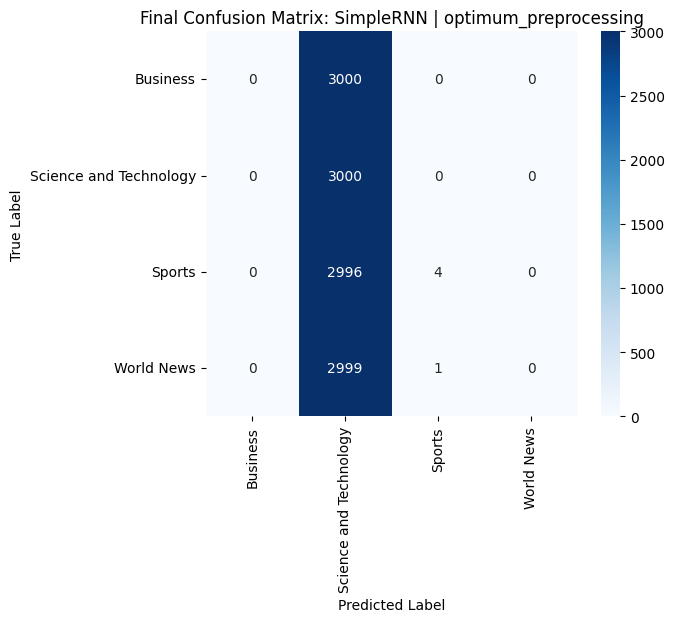

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
17,RUN_25,SimpleRNN,Skip-gram Word2Vec,optimum_preprocessing,0.250333,0.100699,11.59


Epoch 1/10 - loss: 0.4939
Epoch 2/10 - loss: 0.2132
Epoch 3/10 - loss: 0.1645
Epoch 4/10 - loss: 0.1286
Epoch 5/10 - loss: 0.0974
Epoch 6/10 - loss: 0.0708
Epoch 7/10 - loss: 0.0528
Epoch 8/10 - loss: 0.0389
Epoch 9/10 - loss: 0.0310
Epoch 10/10 - loss: 0.0269
Final test result for: RUN_10 Deep Neural Network extreme_preprocessing
Accuracy: 0.9017
Macro F1-score: 0.9014
                        precision    recall  f1-score   support

              Business       0.89      0.83      0.86      3000
Science and Technology       0.85      0.91      0.88      3000
                Sports       0.96      0.97      0.96      3000
            World News       0.91      0.89      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



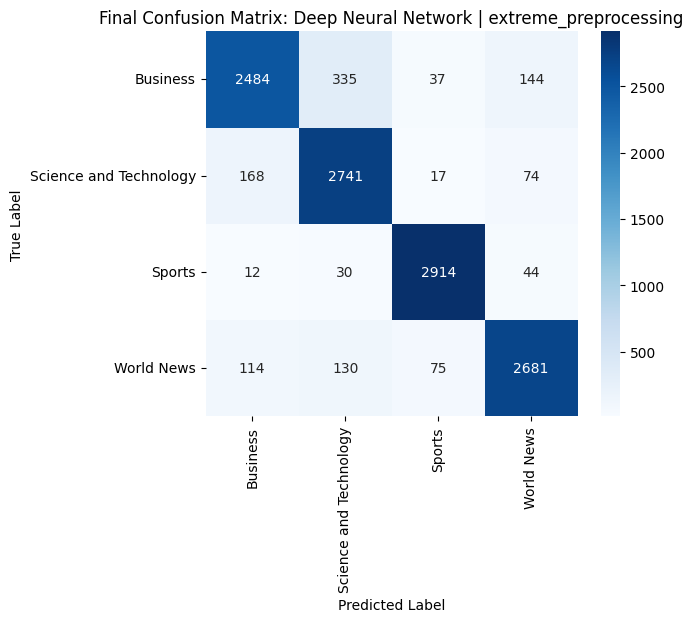

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
18,RUN_10,Deep Neural Network,TF-IDF,extreme_preprocessing,0.901667,0.90139,16.45


Epoch 1/5 - loss: 0.4911
Epoch 2/5 - loss: 0.2206
Epoch 3/5 - loss: 0.1644
Epoch 4/5 - loss: 0.1200
Epoch 5/5 - loss: 0.0850
Final test result for: RUN_07 Deep Neural Network no_preprocessing
Accuracy: 0.9065
Macro F1-score: 0.9064
                        precision    recall  f1-score   support

              Business       0.88      0.86      0.87      3000
Science and Technology       0.87      0.90      0.89      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.92      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



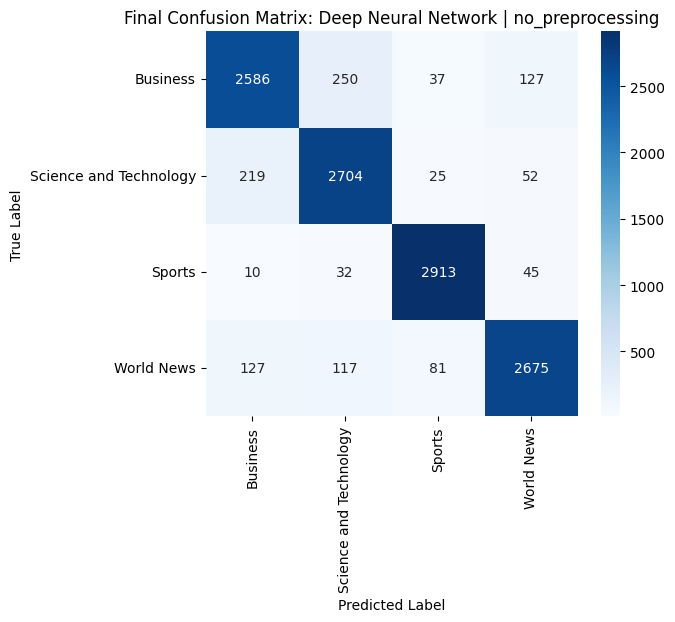

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
19,RUN_07,Deep Neural Network,TF-IDF,no_preprocessing,0.9065,0.906373,8.11


Epoch 1/16 - loss: 0.4841
Epoch 2/16 - loss: 0.2176
Epoch 3/16 - loss: 0.1670
Epoch 4/16 - loss: 0.1284
Epoch 5/16 - loss: 0.0974
Epoch 6/16 - loss: 0.0716
Epoch 7/16 - loss: 0.0533
Epoch 8/16 - loss: 0.0391
Epoch 9/16 - loss: 0.0298
Epoch 10/16 - loss: 0.0250
Epoch 11/16 - loss: 0.0227
Epoch 12/16 - loss: 0.0197
Epoch 13/16 - loss: 0.0172
Epoch 14/16 - loss: 0.0151
Epoch 15/16 - loss: 0.0150
Epoch 16/16 - loss: 0.0132
Final test result for: RUN_12 Deep Neural Network optimum_preprocessing
Accuracy: 0.9018
Macro F1-score: 0.9016
                        precision    recall  f1-score   support

              Business       0.89      0.83      0.86      3000
Science and Technology       0.86      0.90      0.88      3000
                Sports       0.96      0.97      0.96      3000
            World News       0.89      0.91      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weigh

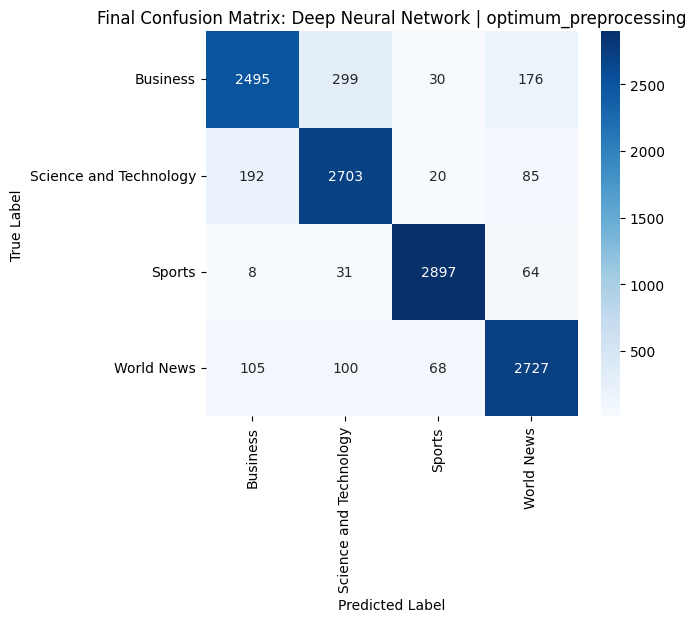

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
20,RUN_12,Deep Neural Network,TF-IDF,optimum_preprocessing,0.901833,0.901563,22.92


Final test result for: RUN_04 Logistic Regression extreme_preprocessing
Accuracy: 0.9148
Macro F1-score: 0.9145
                        precision    recall  f1-score   support

              Business       0.91      0.84      0.88      3000
Science and Technology       0.86      0.94      0.90      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.94      0.90      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.92      0.91      0.91     12000
          weighted avg       0.92      0.91      0.91     12000



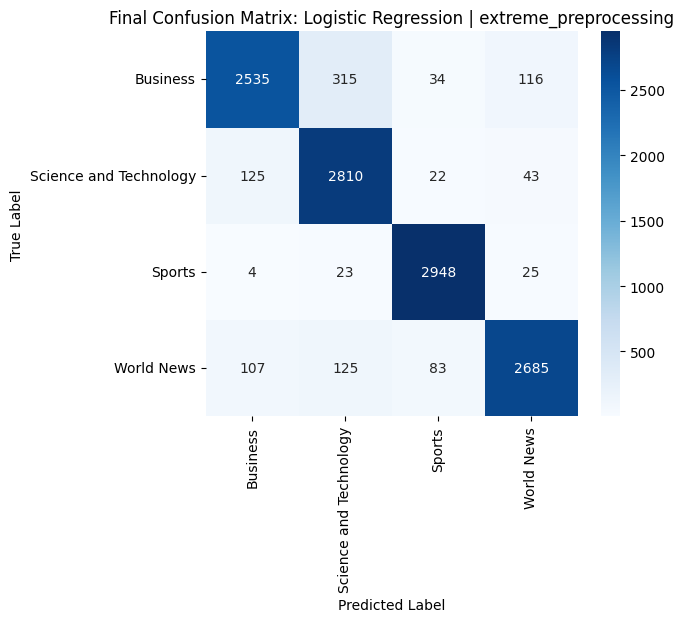

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
21,RUN_04,Logistic Regression,TF-IDF,extreme_preprocessing,0.914833,0.914508,5.54


Final test result for: RUN_02 Logistic Regression no_preprocessing
Accuracy: 0.8937
Macro F1-score: 0.8941
                        precision    recall  f1-score   support

              Business       0.94      0.79      0.86      3000
Science and Technology       0.77      0.97      0.86      3000
                Sports       0.96      0.97      0.96      3000
            World News       0.96      0.84      0.90      3000

              accuracy                           0.89     12000
             macro avg       0.91      0.89      0.89     12000
          weighted avg       0.91      0.89      0.89     12000



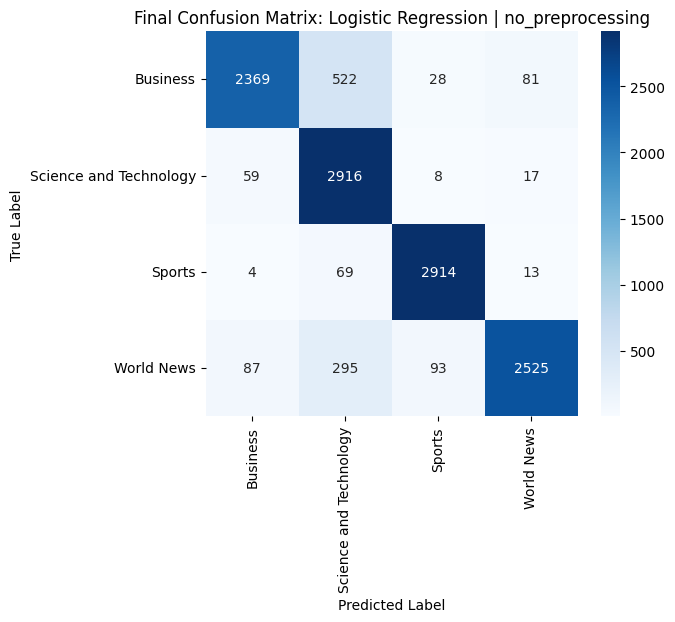

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
22,RUN_02,Logistic Regression,TF-IDF,no_preprocessing,0.893667,0.894083,8.13


Final test result for: RUN_06 Logistic Regression optimum_preprocessing
Accuracy: 0.9158
Macro F1-score: 0.9155
                        precision    recall  f1-score   support

              Business       0.92      0.84      0.88      3000
Science and Technology       0.86      0.94      0.90      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.94      0.90      0.92      3000

              accuracy                           0.92     12000
             macro avg       0.92      0.92      0.92     12000
          weighted avg       0.92      0.92      0.92     12000



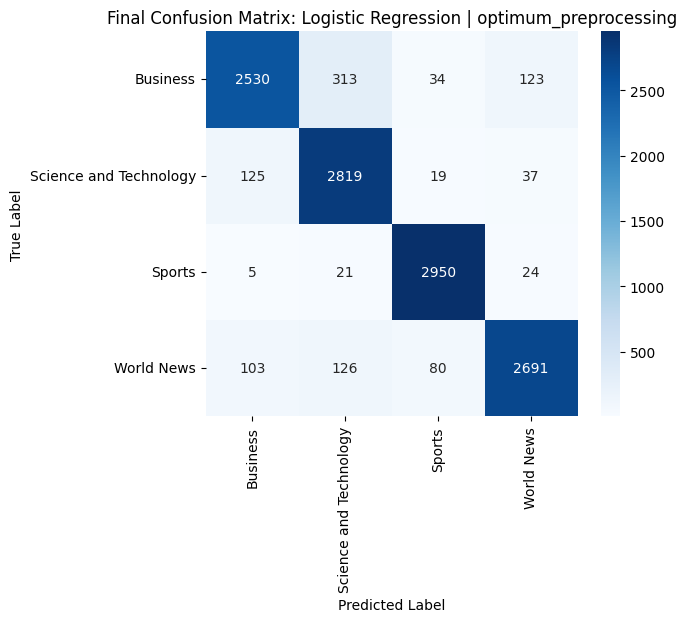

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
23,RUN_06,Logistic Regression,TF-IDF,optimum_preprocessing,0.915833,0.915482,5.85


Final test evaluation completed.


In [ ]:
# Run final test evaluation for the selected configurations
final_test_results = []

for row_index, config_row in selected_validation_configs.iterrows():
    if config_row["model"] == "Logistic Regression":
        final_result = evaluate_final_tfidf_lr(config_row)
    elif config_row["model"] == "Deep Neural Network":
        final_result = evaluate_final_tfidf_dnn(config_row)
    else:
        final_result = evaluate_final_skipgram_sequence(config_row)
    final_test_results.append(final_result)
    final_test_df = pd.DataFrame(final_test_results)
    final_test_df.to_csv(os.path.join(OUTPUT_DIR, "final_test_results.csv"), index=False)
    display(final_test_df.tail(1))

print("Final test evaluation completed.")

# **11. Final Result Tables and Visual Comparison**

In [ ]:
# Display the final test results table
final_test_path = os.path.join(OUTPUT_DIR, "final_test_results.csv")
final_test_df = pd.read_csv(final_test_path).sort_values("test_macro_f1", ascending=False)

display(final_test_df)

,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
23,RUN_06,Logistic Regression,TF-IDF,optimum_preprocessing,0.915833,0.915482,5.85
21,RUN_04,Logistic Regression,TF-IDF,extreme_preprocessing,0.914833,0.914508,5.54
3,RUN_24,Bidirectional LSTM,Skip-gram Word2Vec,extreme_preprocessing,0.907000,0.906426,14.66
19,RUN_07,Deep Neural Network,TF-IDF,no_preprocessing,0.906500,0.906373,8.11
5,RUN_30,Bidirectional LSTM,Skip-gram Word2Vec,optimum_preprocessing,0.906083,0.905916,14.85
9,RUN_20,GRU,Skip-gram Word2Vec,extreme_preprocessing,0.904667,0.904227,11.02
2,RUN_29,Bidirectional GRU,Skip-gram Word2Vec,optimum_preprocessing,0.904667,0.904050,14.70
0,RUN_23,Bidirectional GRU,Skip-gram Word2Vec,extreme_preprocessing,0.901917,0.901749,14.78
20,RUN_12,Deep Neural Network,TF-IDF,optimum_preprocessing,0.901833,0.901563,22.92
18,RUN_10,Deep Neural Network,TF-IDF,extreme_preprocessing,0.901667,0.901390,16.45


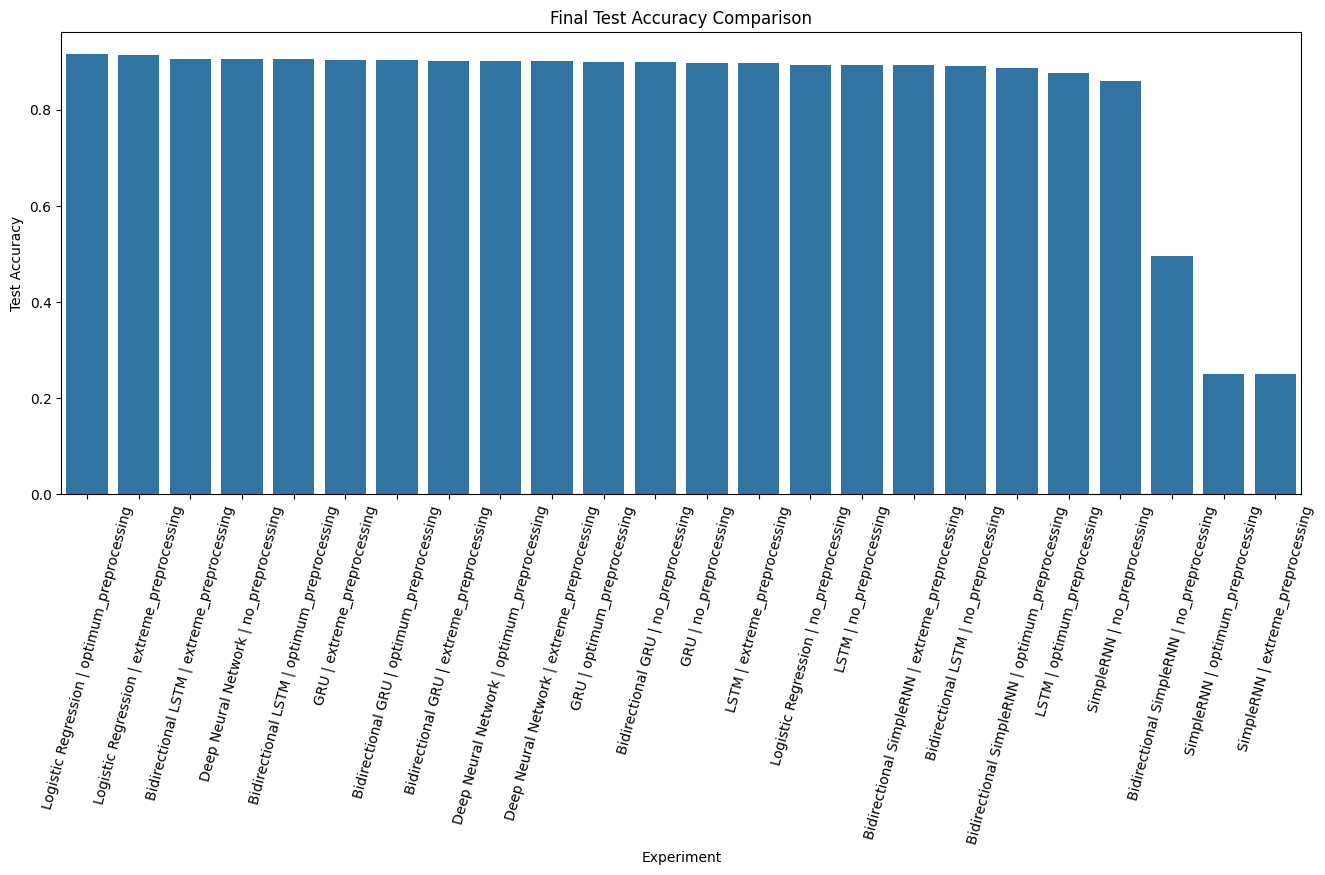

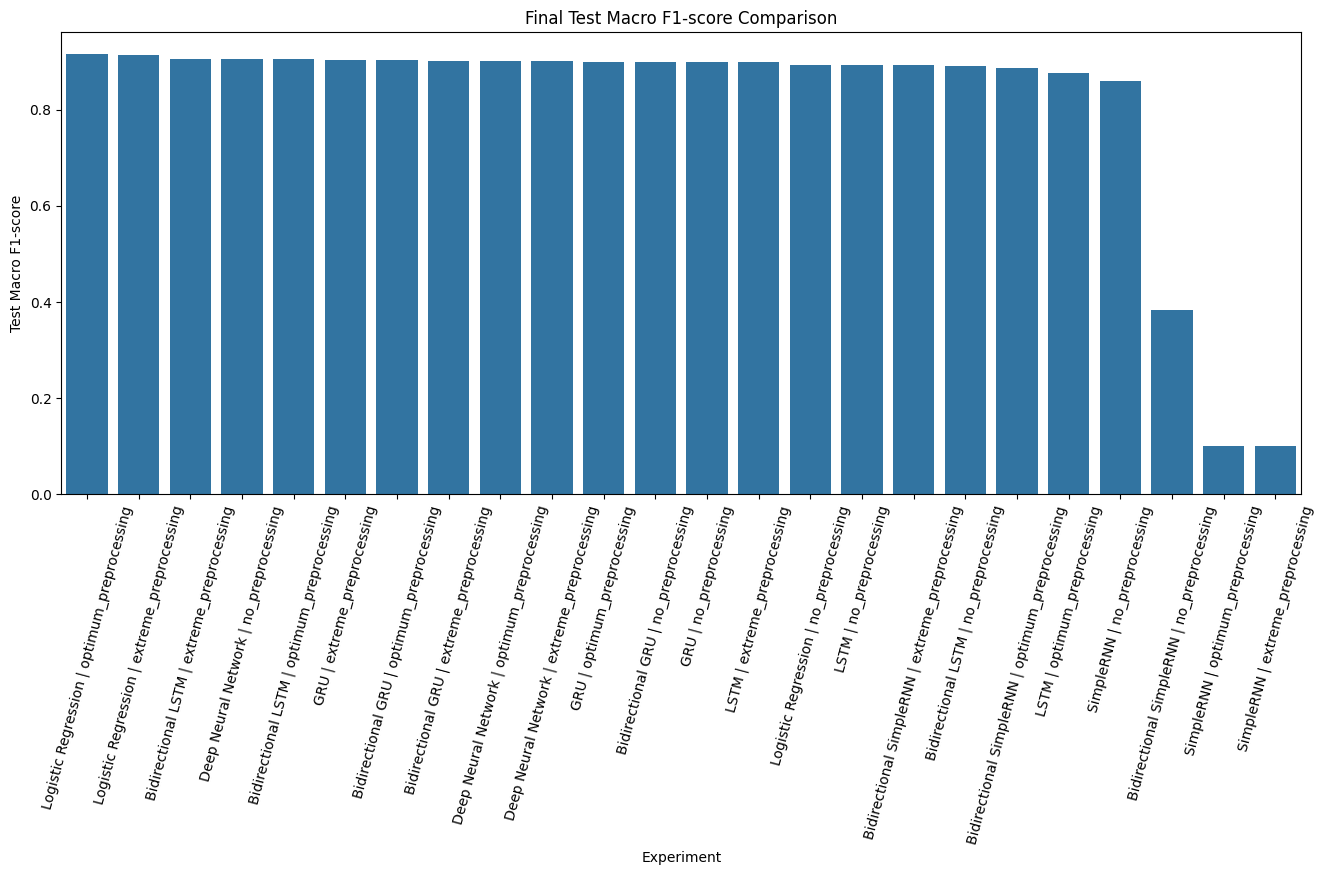

In [ ]:
# Plot final test accuracy and macro F1-score
final_plot_df = final_test_df.copy()
final_plot_df["experiment"] = final_plot_df["model"] + " | " + final_plot_df["preprocessing"]

plt.figure(figsize=(16, 6))
sns.barplot(data=final_plot_df, x="experiment", y="test_accuracy")
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Experiment")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(16, 6))
sns.barplot(data=final_plot_df, x="experiment", y="test_macro_f1")
plt.title("Final Test Macro F1-score Comparison")
plt.xlabel("Experiment")
plt.ylabel("Test Macro F1-score")
plt.xticks(rotation=75)
plt.show()

In [ ]:
# Identify best and worst final test experiments
best_final = final_test_df.iloc[0]
worst_final = final_test_df.iloc[-1]

print("Best final test experiment:")
display(best_final.to_frame().T)
print("Worst final test experiment:")
display(worst_final.to_frame().T)

Best final test experiment:


,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
23,RUN_06,Logistic Regression,TF-IDF,optimum_preprocessing,0.915833,0.915482,5.85


Worst final test experiment:


,source_run_id,model,representation,preprocessing,test_accuracy,test_macro_f1,runtime_seconds
15,RUN_19,SimpleRNN,Skip-gram Word2Vec,extreme_preprocessing,0.250167,0.100346,11.26
